In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

from experiments.border_bias.predictions import stimulus
from v1sh_model.inputs.visualize import visualize_input, visualize_output

In [2]:
saliency_maps = np.load("../../../data/results/border_predictions_T=12_dt=0.01/border_maps_predictions.npz")

In [3]:
saliency_maps

NpzFile '../../../data/results/border_predictions_T=12_dt=0.01/border_maps_predictions.npz' with keys: N_row=1_I_input=2.0, N_row=2_I_input=2.0, N_row=3_I_input=2.0, N_row=4_I_input=2.0, N_row=5_I_input=2.0...

In [4]:
def border_saliency_and_bias_1(saliency_map, n_neighbors = 3, verbose = False):
    z_score = (saliency_map - np.mean(saliency_map[saliency_map != 0.0])) / np.std(saliency_map[saliency_map != 0.0])
    N_x = saliency_map.shape[1]
    border_idx = N_x // 2 # column right next to the border
    border_saliency_distr = z_score[:, border_idx - n_neighbors:border_idx + n_neighbors].max(axis = 0)
    border_saliency = np.max(border_saliency_distr) 
    max_indices = np.nonzero(border_saliency_distr == border_saliency)[0]
    bias = - (np.mean(max_indices) - n_neighbors + 0.5) # negative because texture parallel to border is left for X_gen
    
    if verbose:
        print(f"Border saliency: {border_saliency}")
        print(f"Border bias: {bias}")
        
        plt.hist(z_score.flatten(), bins=50)
        plt.title("Histogram of output activations")
        plt.axvline(border_saliency, color='red', linestyle='dashed', linewidth=1)
        plt.xlabel("Z-score of output activation")
        plt.ylabel("Frequency")
        plt.title(f"Border saliency: {border_saliency:.2f}")
        plt.yscale('log')
        plt.show()
        
        plt.bar(np.arange(-n_neighbors, + n_neighbors, 1) + 0.5, border_saliency_distr[::-1])
        plt.axvline(0, color = "green", linestyle = "dashed", linewidth = 1, label = "Texture border")
        plt.axvline(bias, color = "red", linestyle = "dashed", linewidth = 1, label = "Predicted bias")
        plt.ylabel("Column saliency (z-score)")
        plt.xlabel("Distance from border towards texture parallel to border (columns)")
        plt.legend()
        plt.title(f"Border bias: {bias}")
        plt.show()
    
    return border_saliency, bias

def border_saliency_and_bias_2(saliency_map, n_neighbors = 3, verbose = False):
    # find most salient column parallel and near to border
    column_saliencies = np.mean(saliency_map, axis = 0)
    saliences_of_border_columns = column_saliencies[saliency_map.shape[1]//2 - n_neighbors : saliency_map.shape[1]//2 + n_neighbors]
    border_saliency = np.max(saliences_of_border_columns)
    border_z_score = (border_saliency - np.mean(saliency_map[saliency_map != 0.0])) / np.std(saliency_map[saliency_map != 0.0])
    
    # bias = average column distance weighted by column saliencies
    border_column_indices = - (np.arange(-n_neighbors, n_neighbors, 1) + 0.5) # negative because texture parallel to border is left for X_gen
    bias = border_column_indices[np.argmax(saliences_of_border_columns)]

    if verbose:
        print(f"Border saliency: {border_saliency}")
        print(f"Border bias: {bias}")
        
        z_score_map = (saliency_map - np.mean(saliency_map[saliency_map != 0.0])) / np.std(saliency_map[saliency_map != 0.0])
        plt.hist(z_score_map.flatten(), bins=50)
        plt.axvline(border_z_score, color='red', linestyle='dashed', linewidth=1)
        plt.xlabel("Saliency distribution")
        plt.ylabel("Frequency")
        plt.title(f"Border saliency: {border_z_score:.2f}")
        plt.yscale('log')
        plt.show()
        
        z_score_of_border_columns = (saliences_of_border_columns - np.mean(saliency_map[saliency_map != 0.0])) / np.std(saliency_map[saliency_map != 0.0])
        plt.bar(np.arange(-n_neighbors, + n_neighbors, 1) + 0.5, z_score_of_border_columns[::-1])
        plt.axvline(0, color = "green", linestyle = "dashed", linewidth = 1, label = "Texture border")
        plt.axvline(bias, color = "red", linestyle = "dashed", linewidth = 1, label = "Predicted bias")
        plt.ylabel("Column saliency (z-score)")
        plt.xlabel("Distance from border towards texture parallel to border (columns)")
        plt.legend()
        plt.title(f"Border bias: {bias}")
        plt.show()
    
    return border_z_score, bias

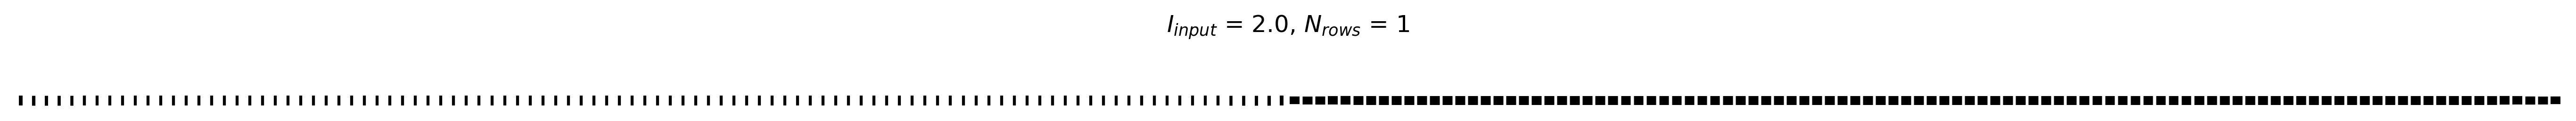

Border saliency: 0.8288740721592597
Border bias: -2.5


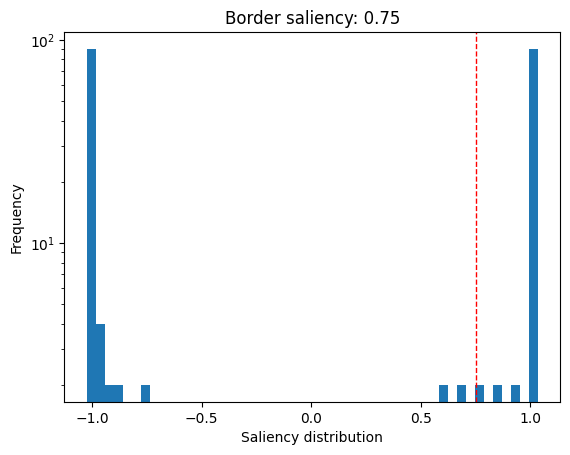

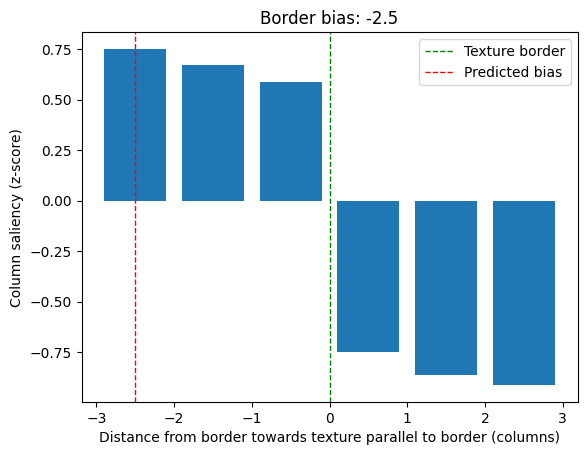

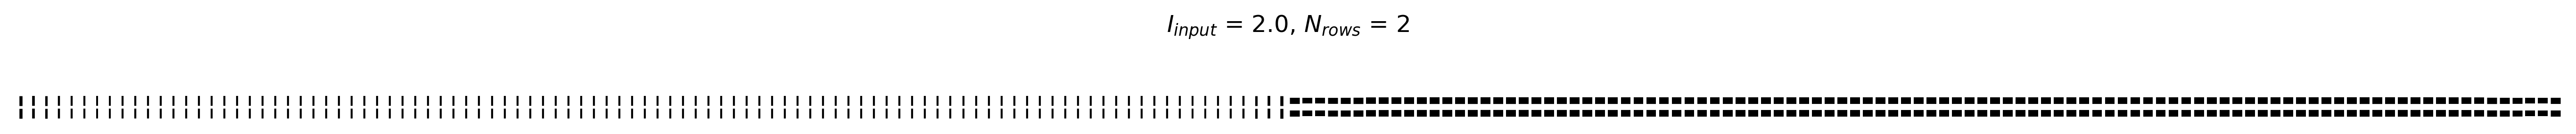

Border saliency: 0.6287859678981209
Border bias: -0.5


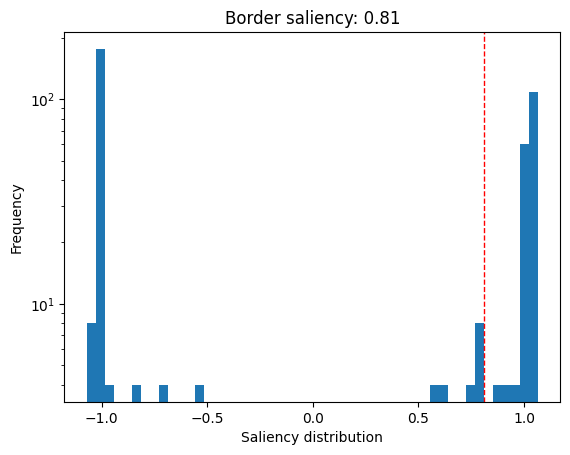

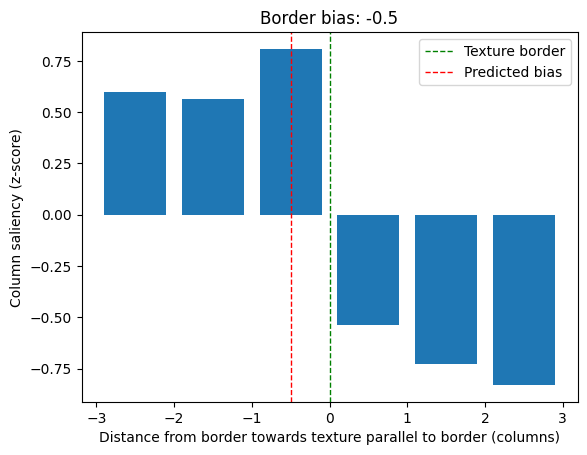

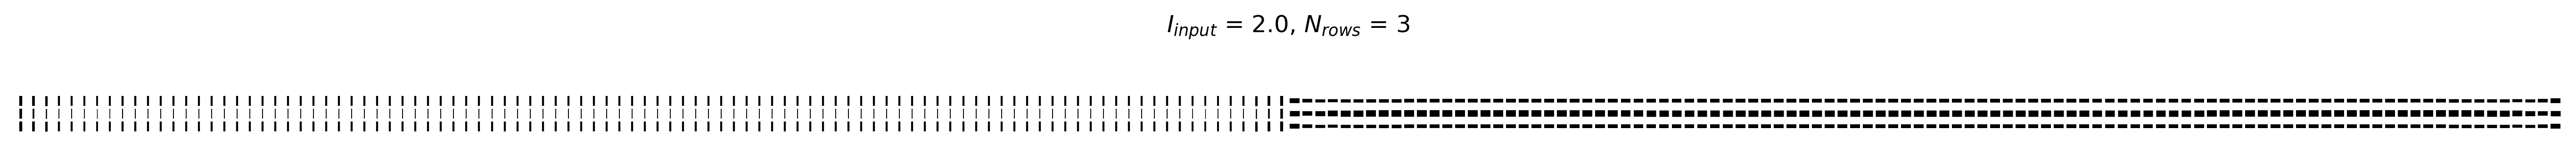

Border saliency: 0.5088790331391787
Border bias: -0.5


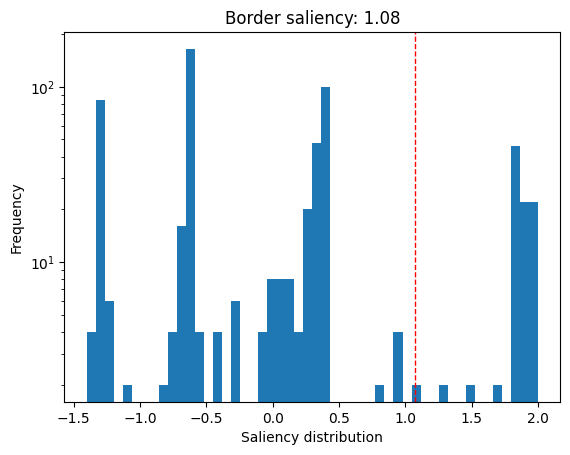

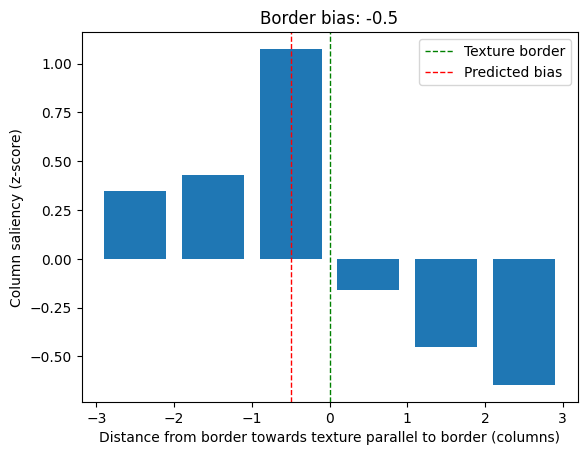

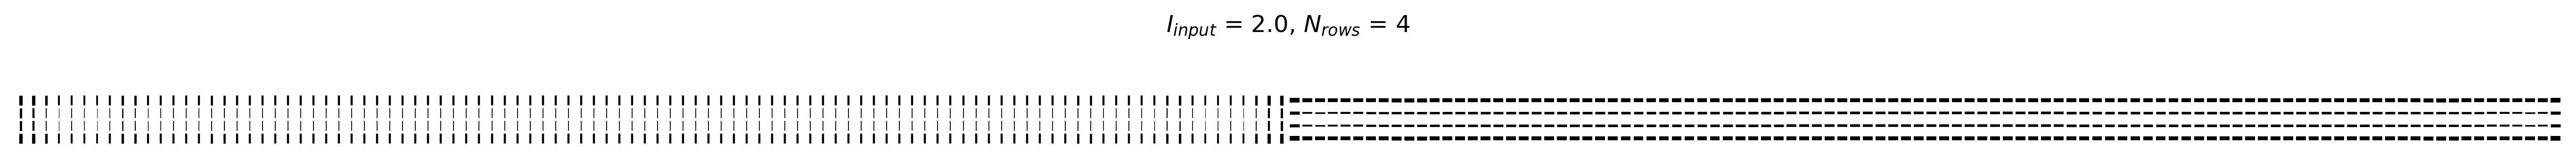

Border saliency: 0.3971843900760725
Border bias: -0.5


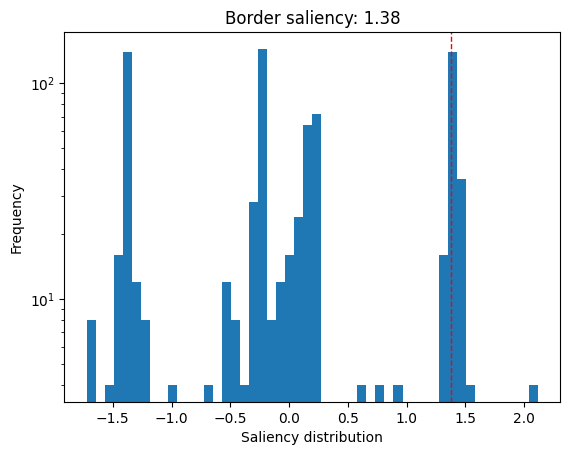

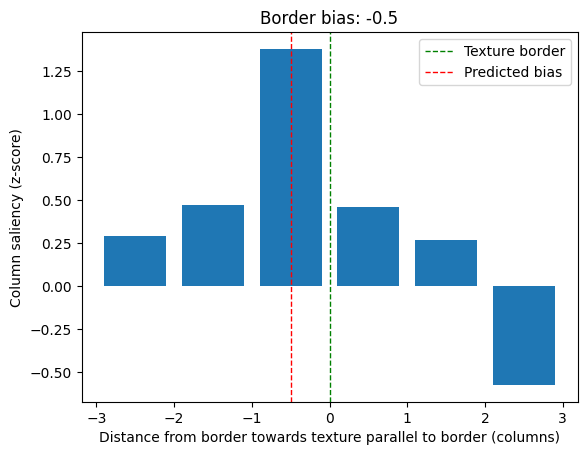

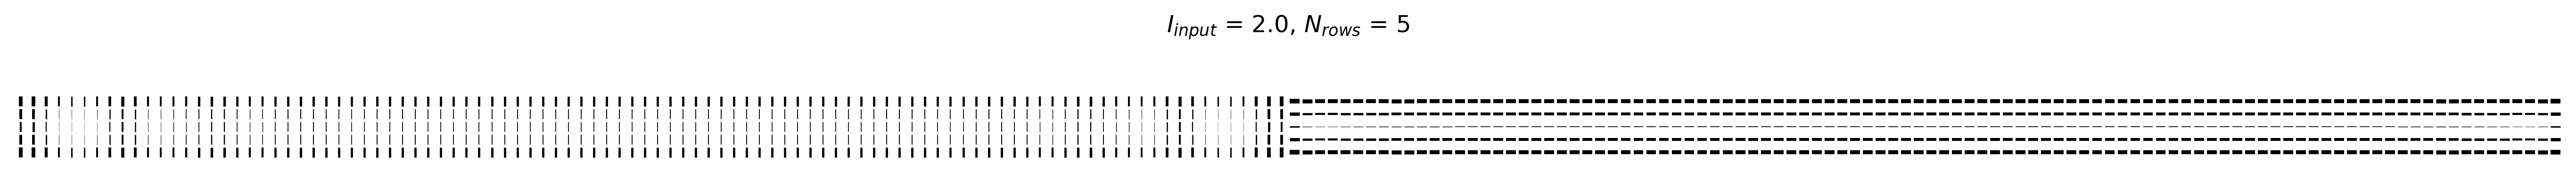

Border saliency: 0.350945677333167
Border bias: -0.5


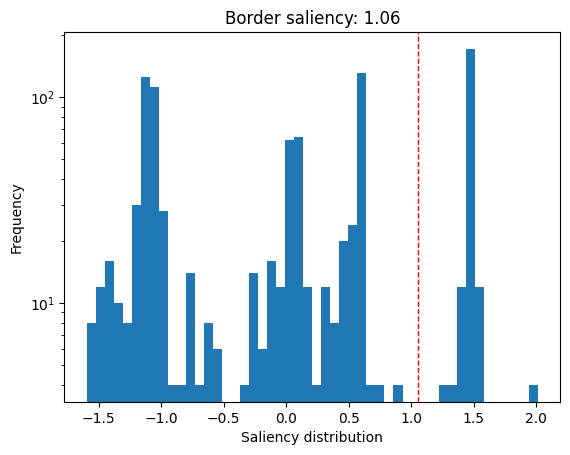

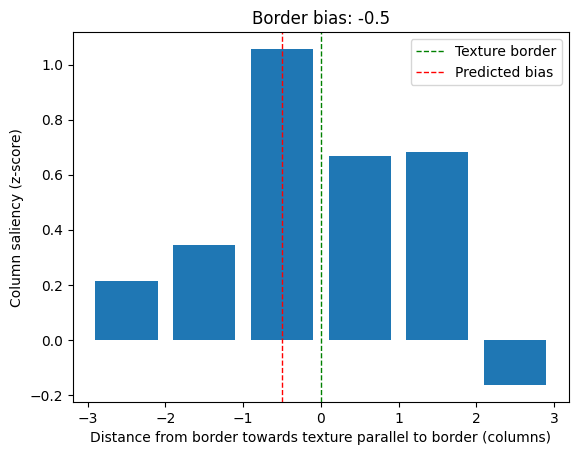

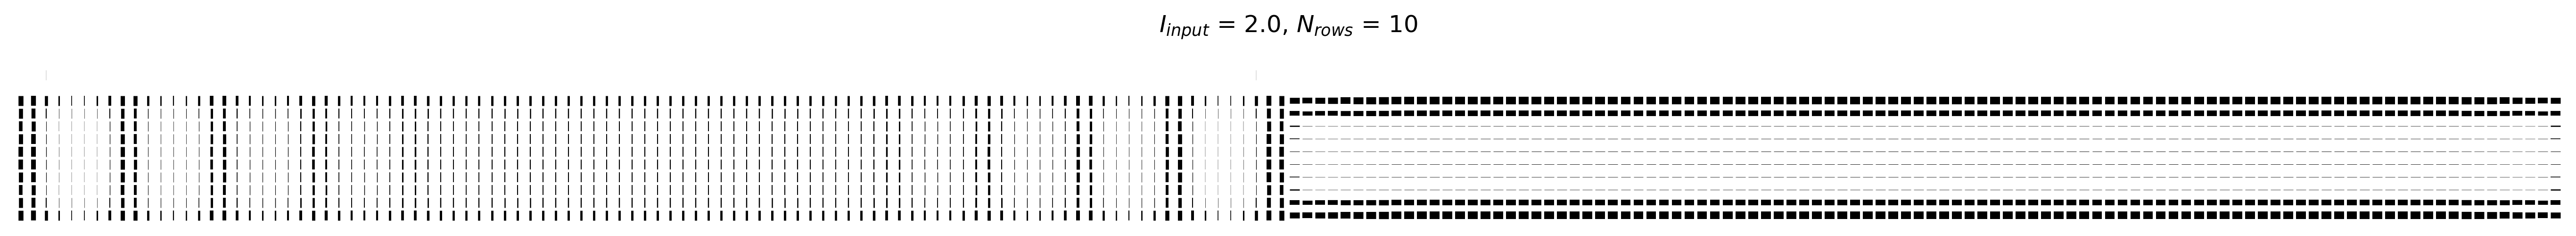

Border saliency: 0.45175593758921506
Border bias: 1.5


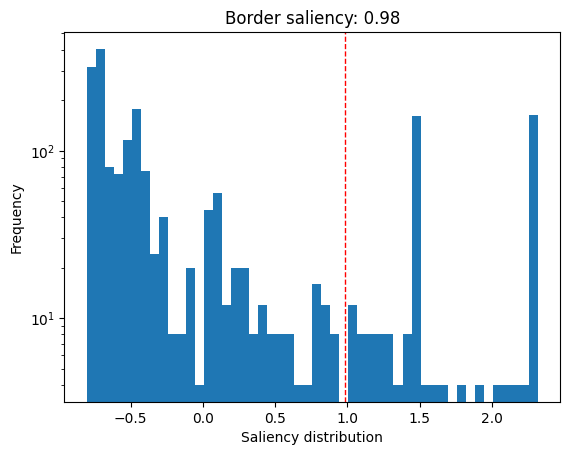

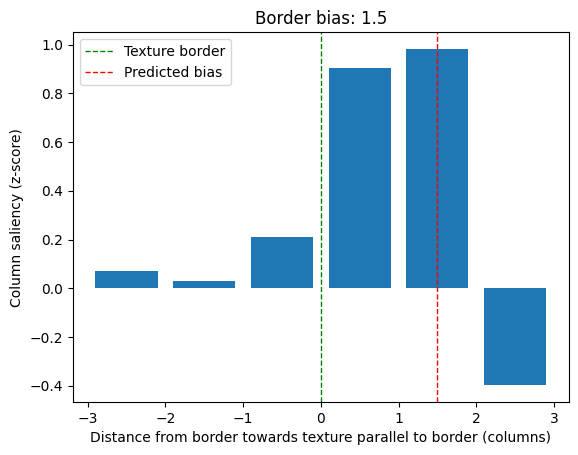

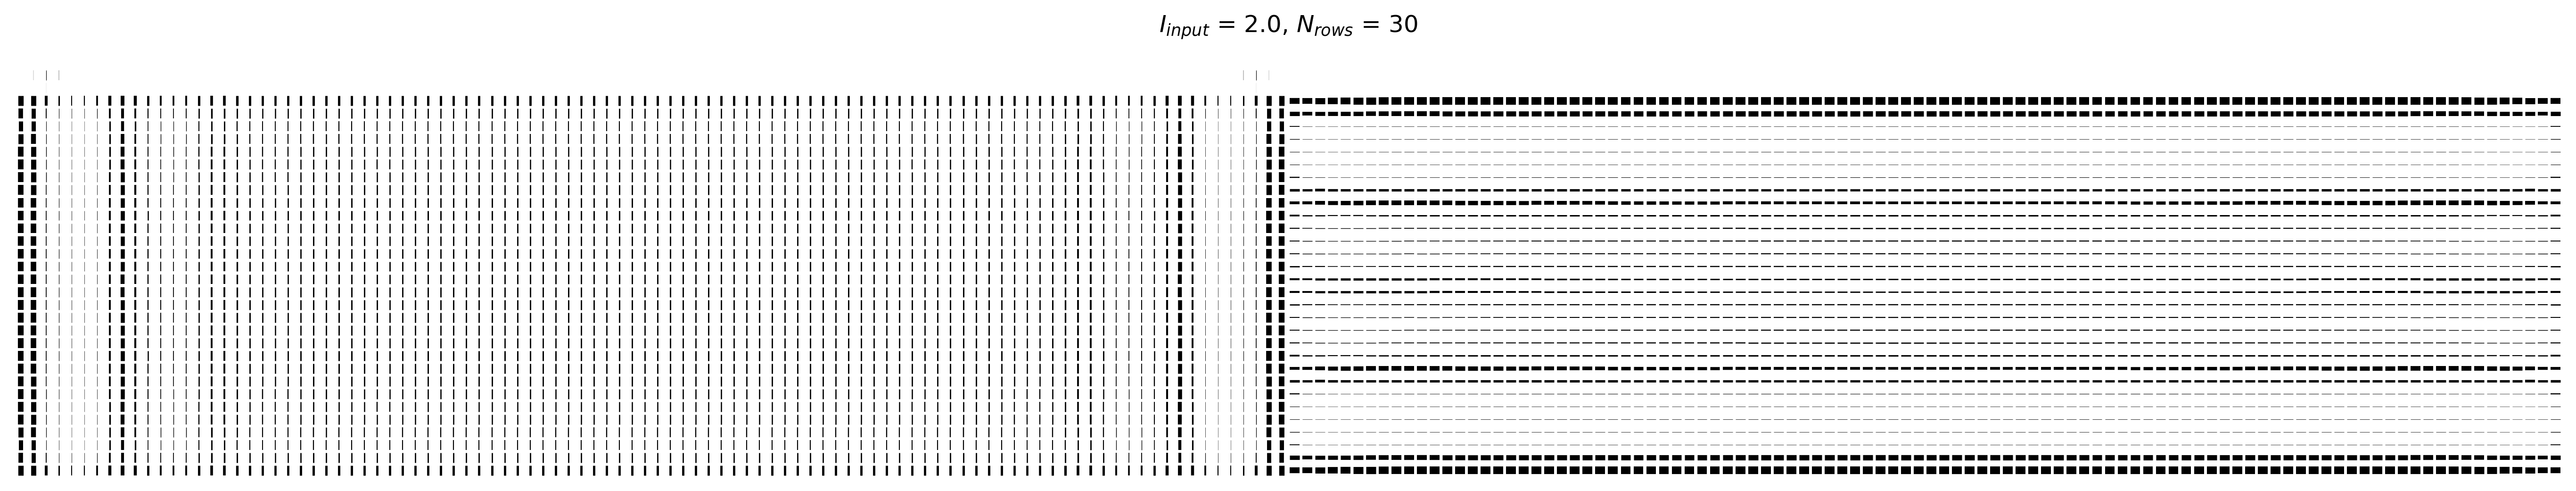

Border saliency: 0.5511061959062467
Border bias: 0.5


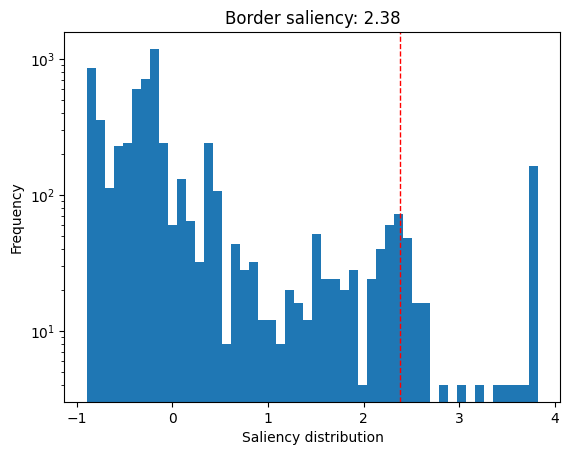

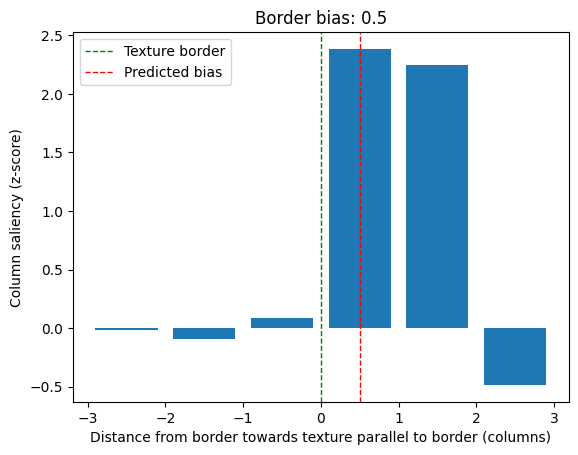

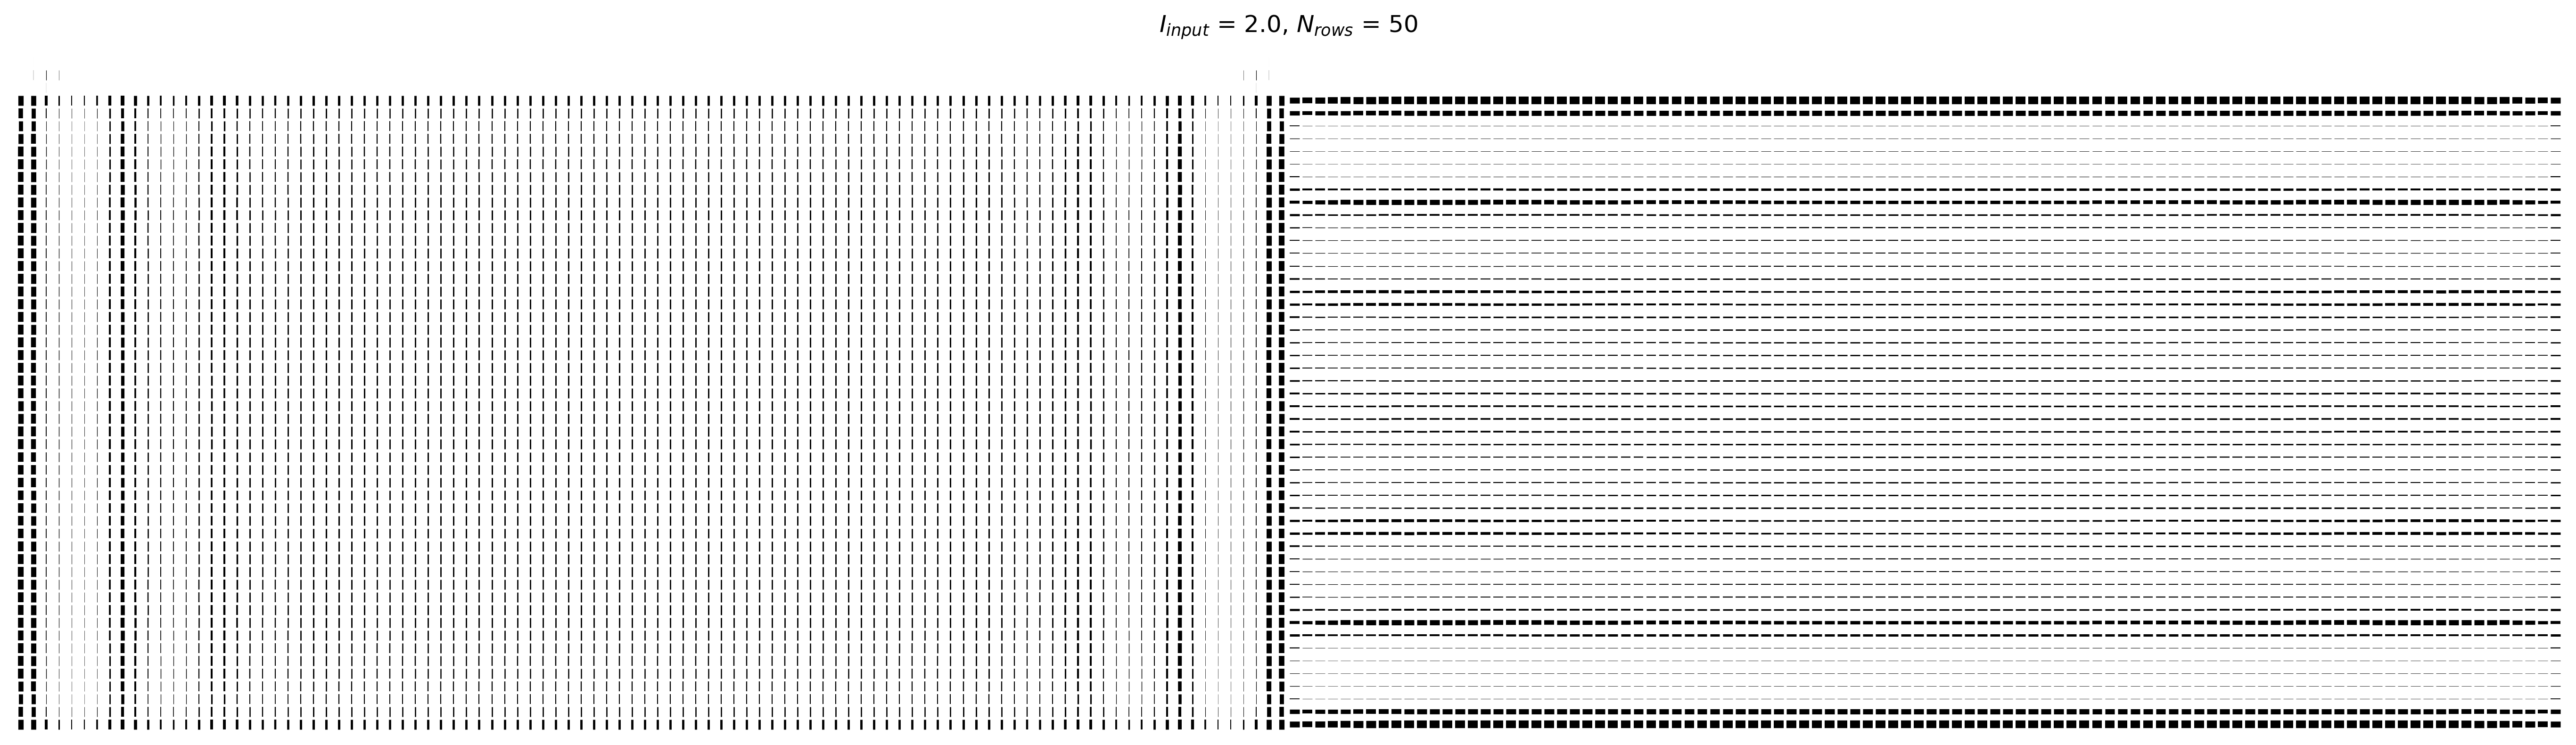

Border saliency: 0.5500498855405164
Border bias: 0.5


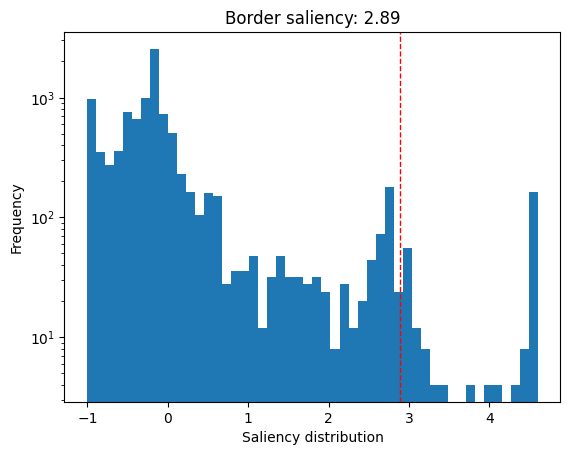

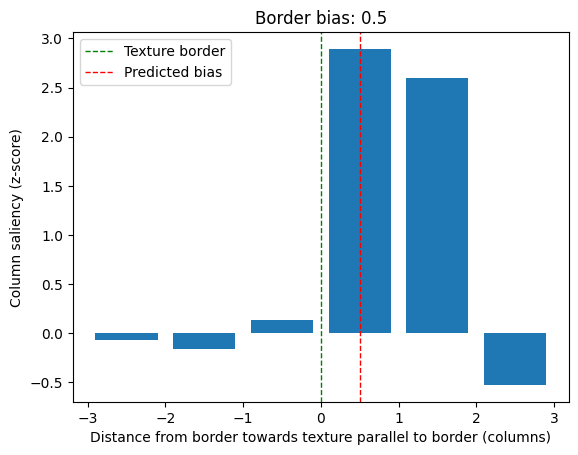

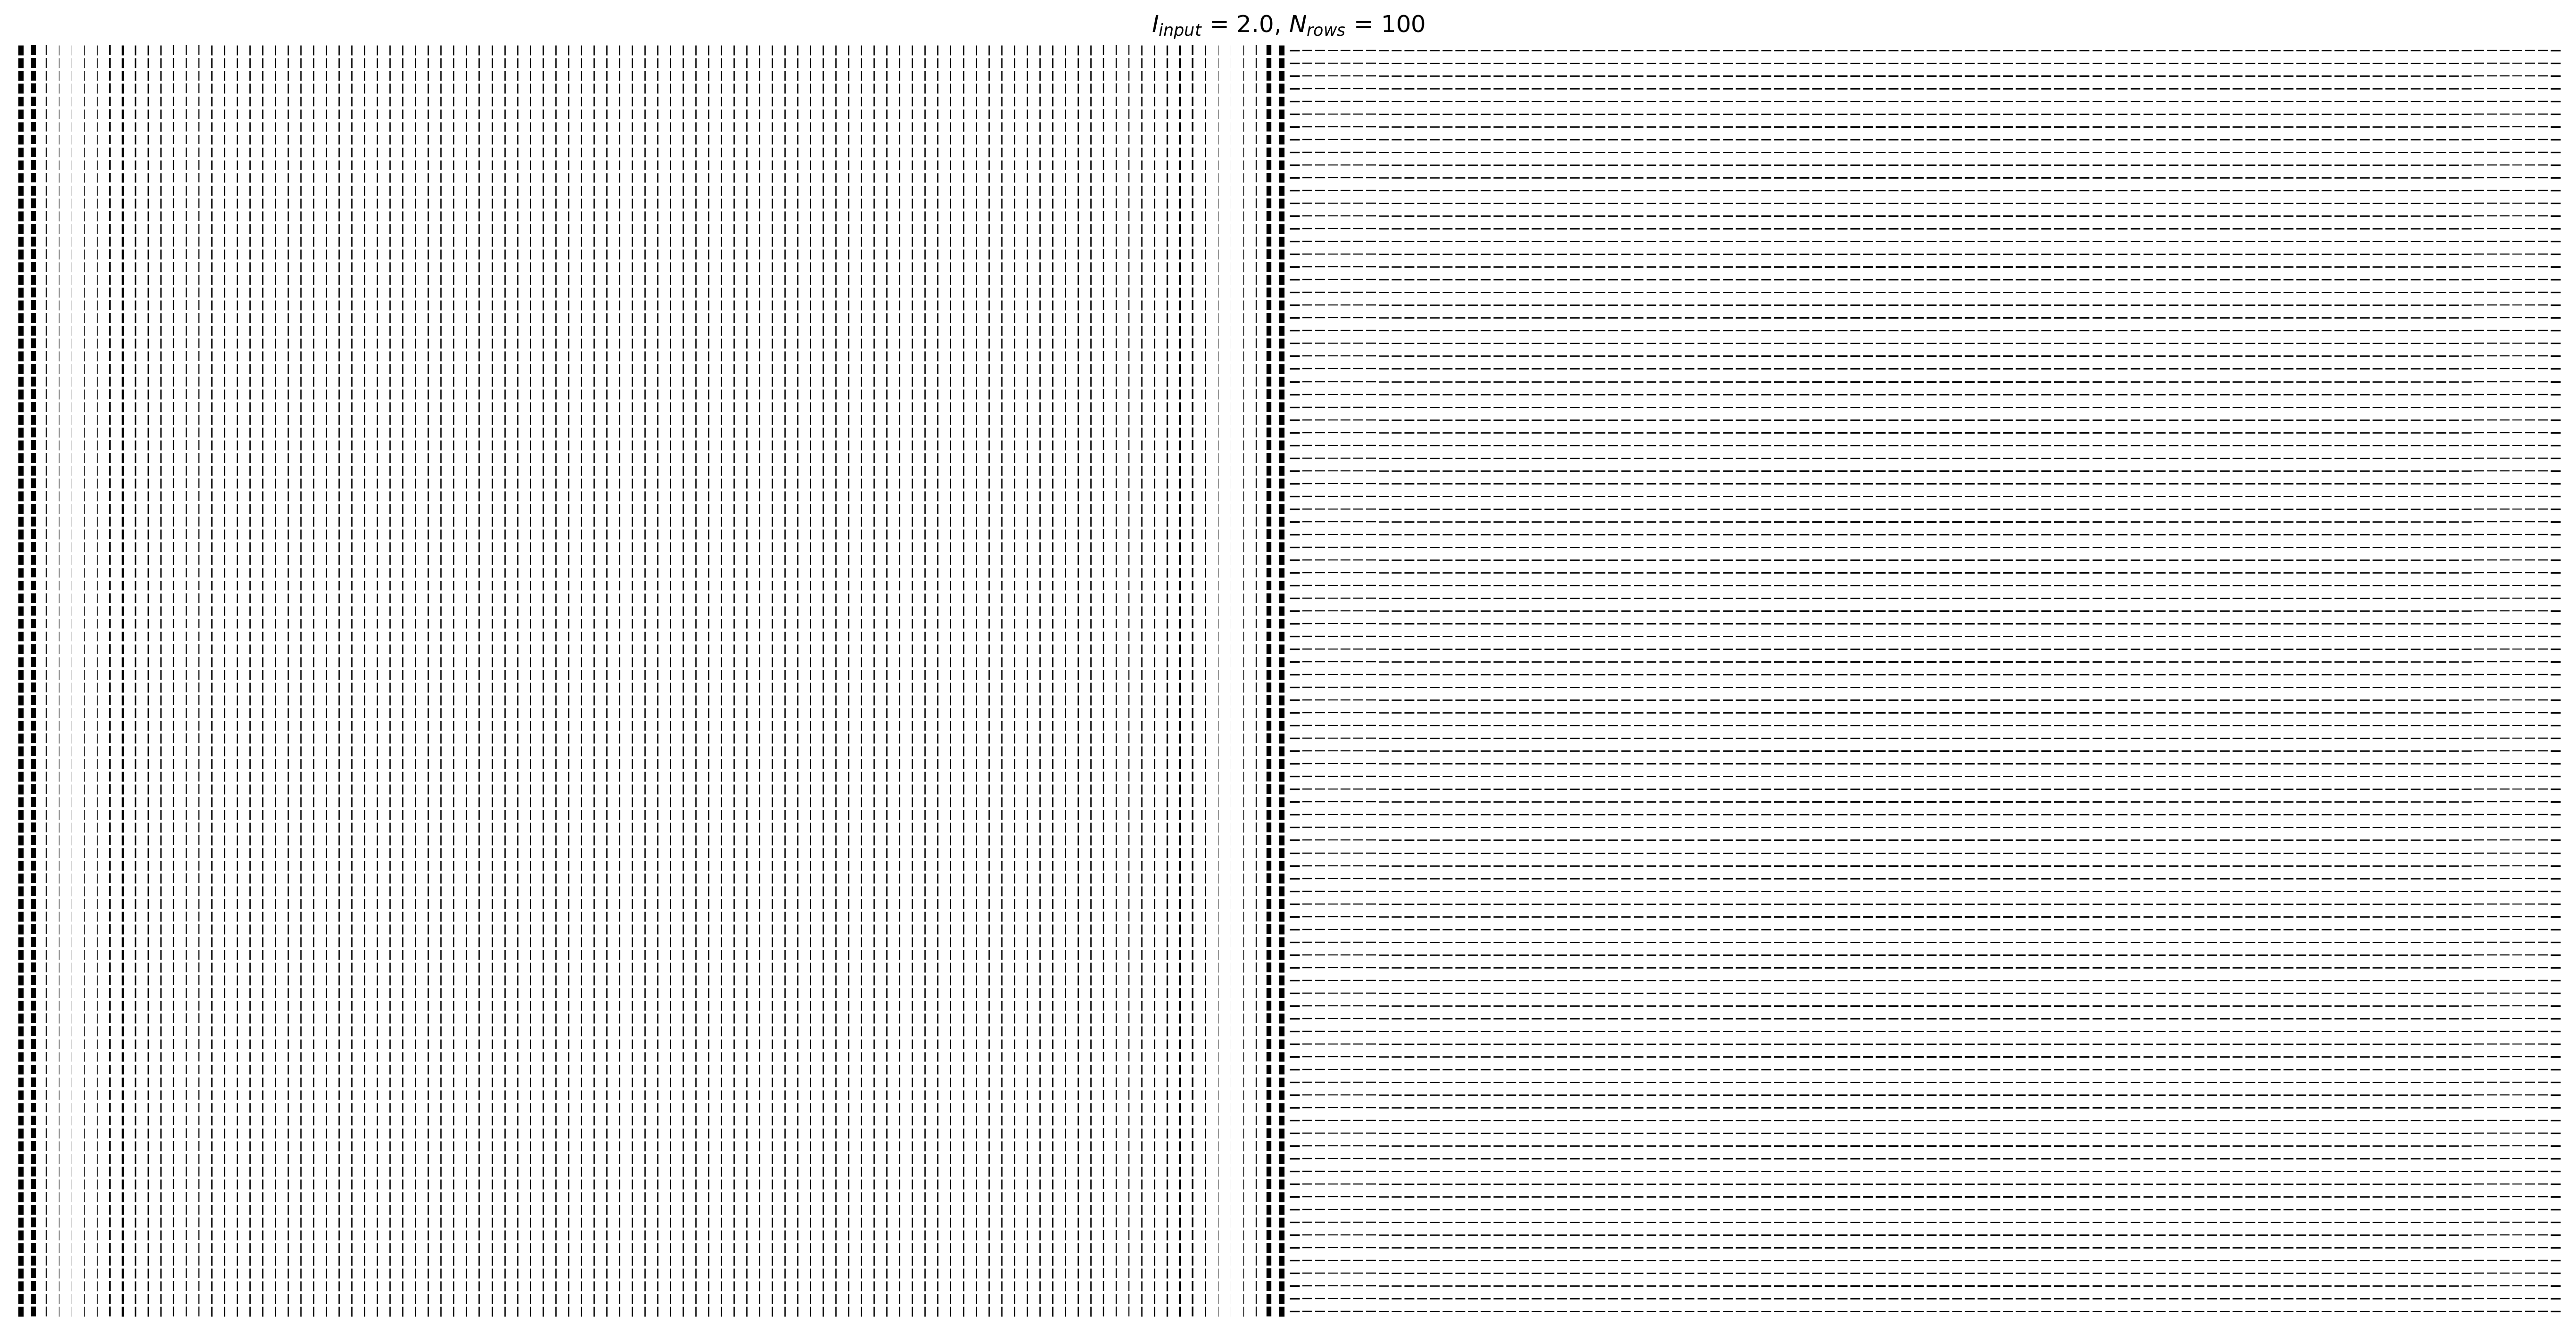

Border saliency: 0.5391674603093226
Border bias: 0.5


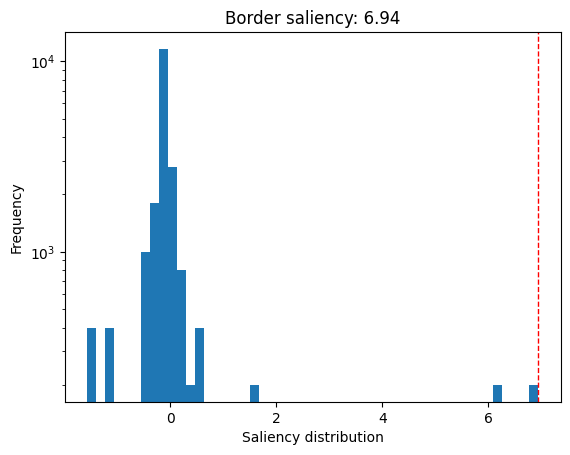

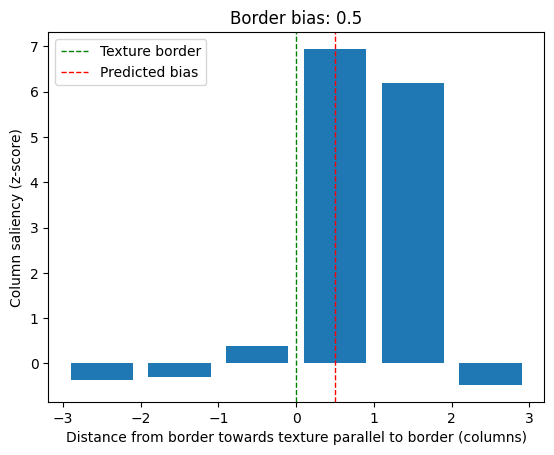

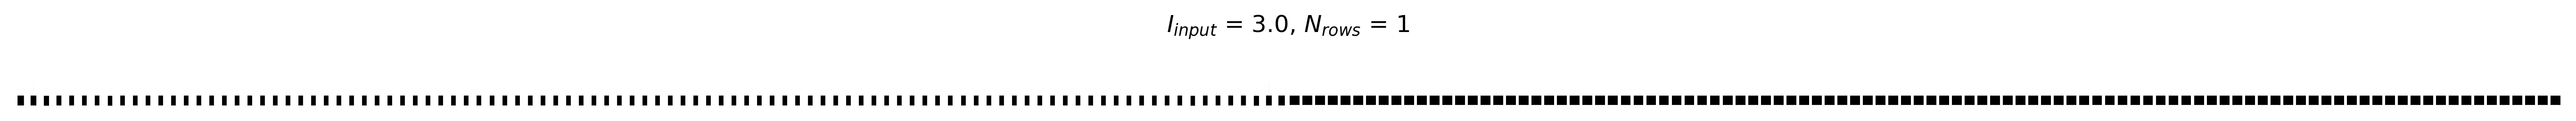

Border saliency: 0.9479783392131247
Border bias: -2.5


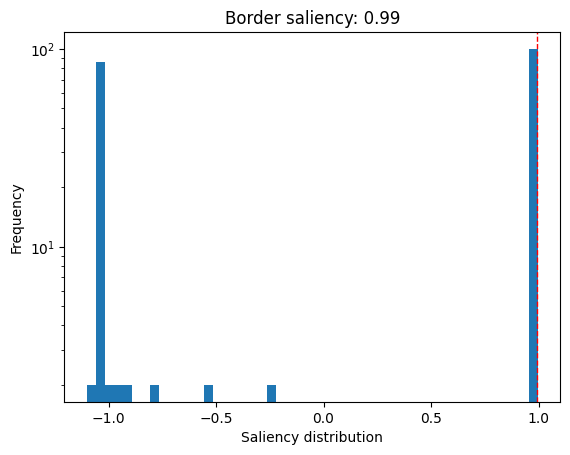

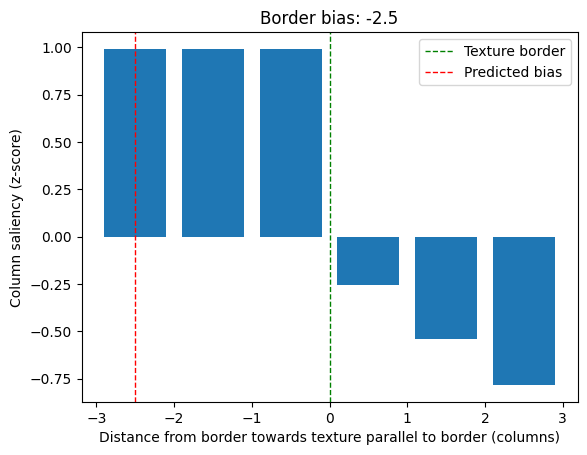

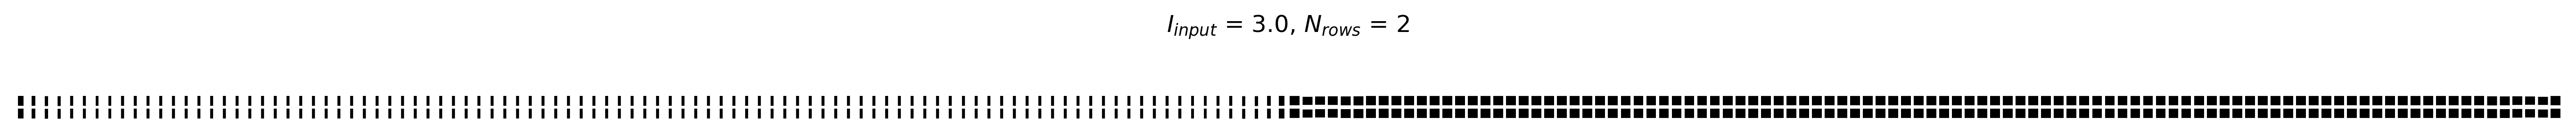

Border saliency: 0.948245305621103
Border bias: -0.5


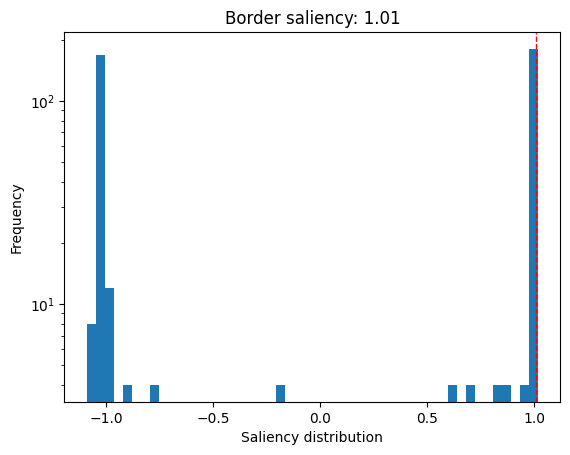

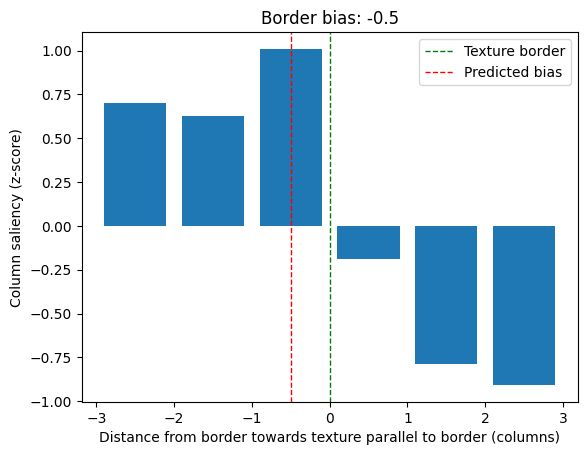

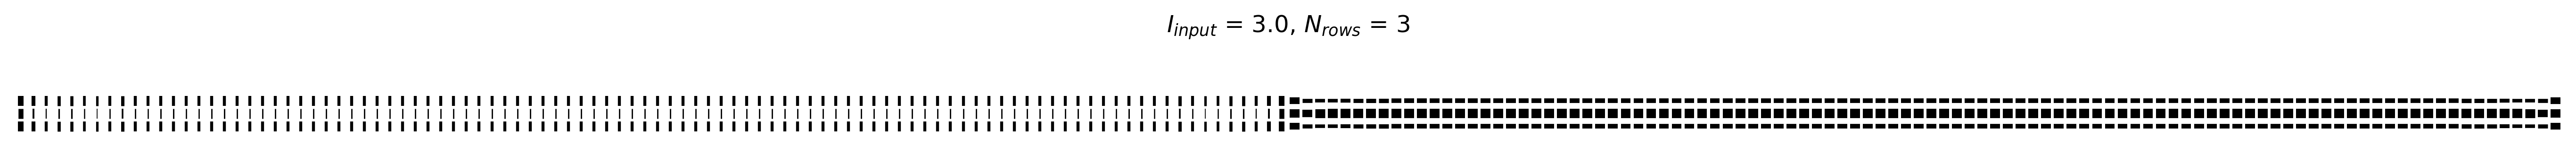

Border saliency: 0.7382325146877742
Border bias: -0.5


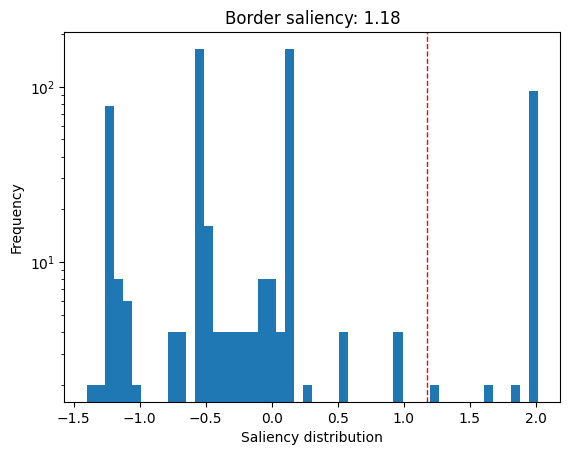

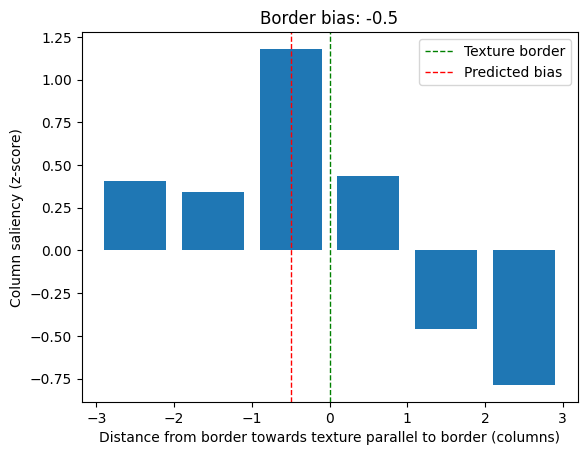

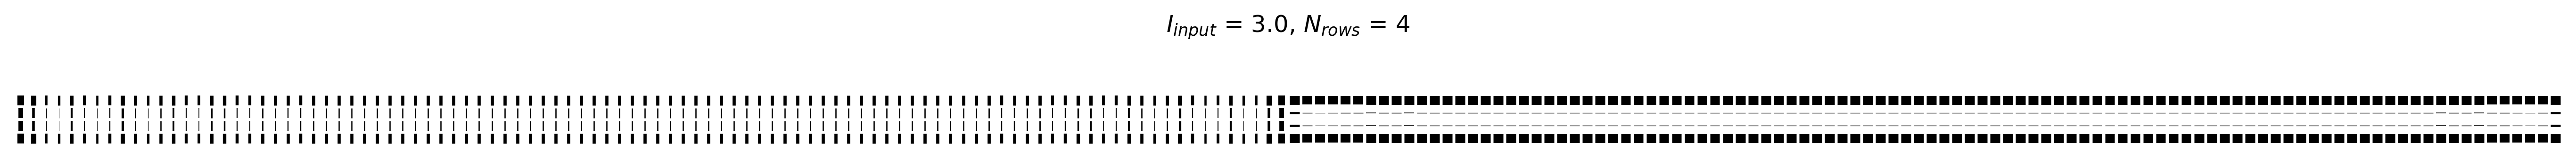

Border saliency: 0.5733247831542463
Border bias: 0.5


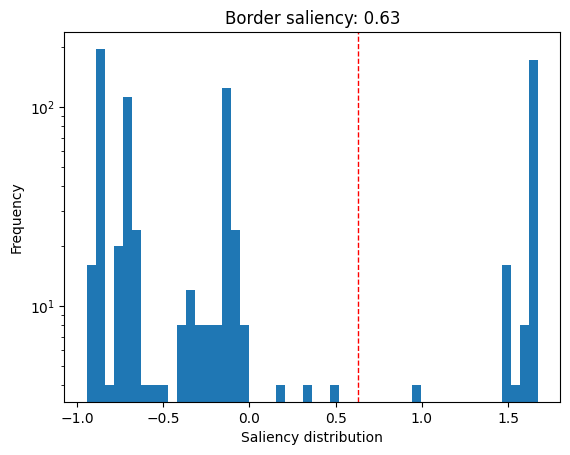

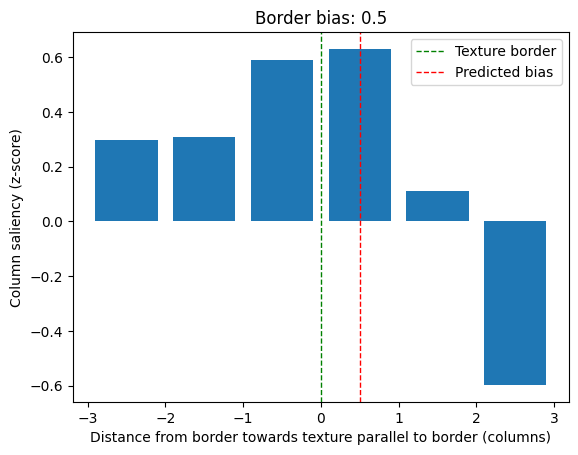

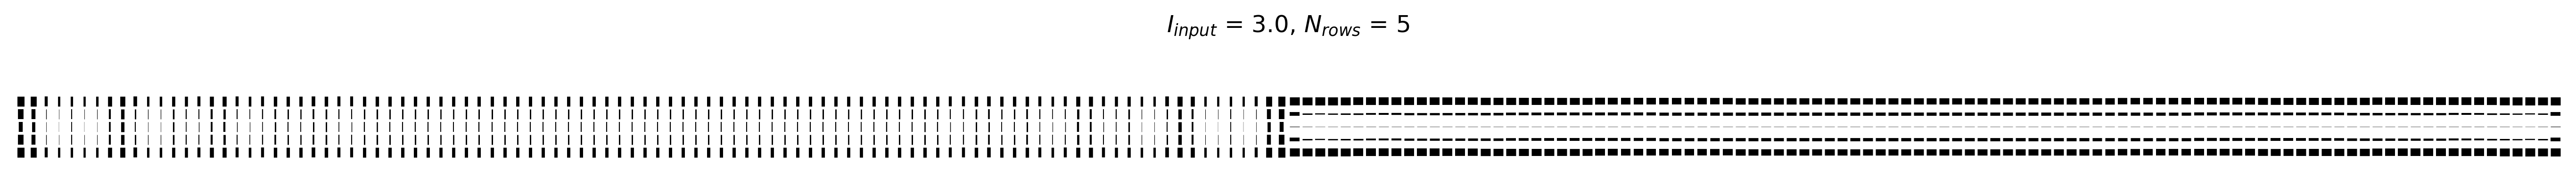

Border saliency: 0.5963448586745551
Border bias: 0.5


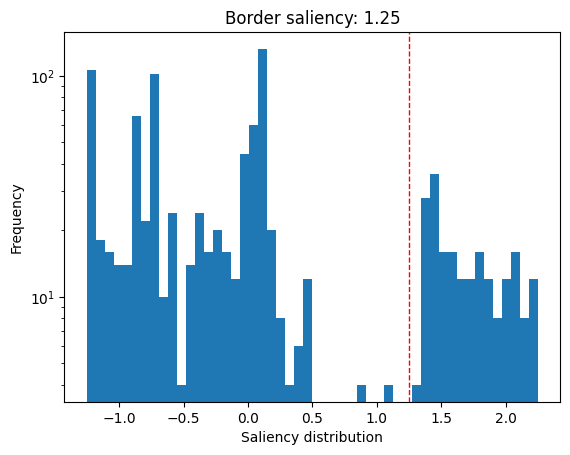

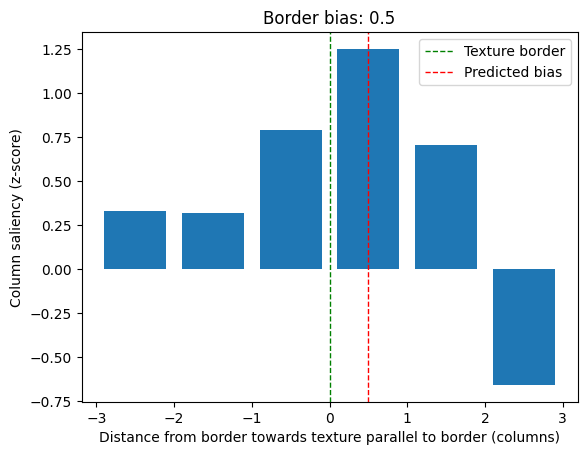

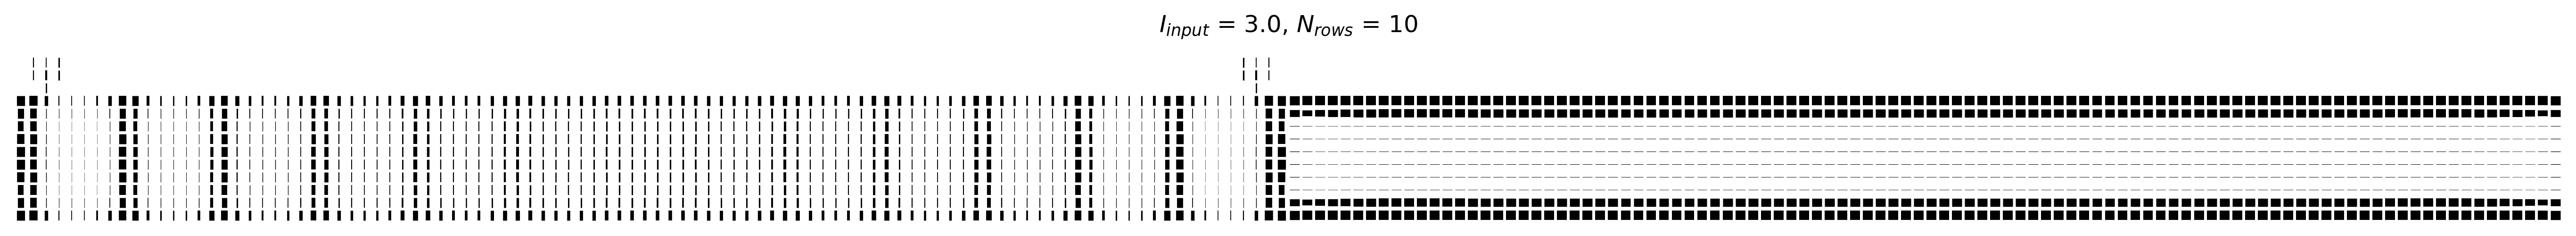

Border saliency: 0.7213578584936557
Border bias: 0.5


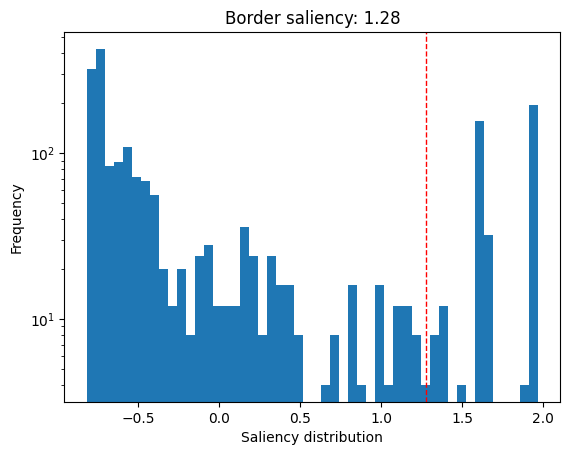

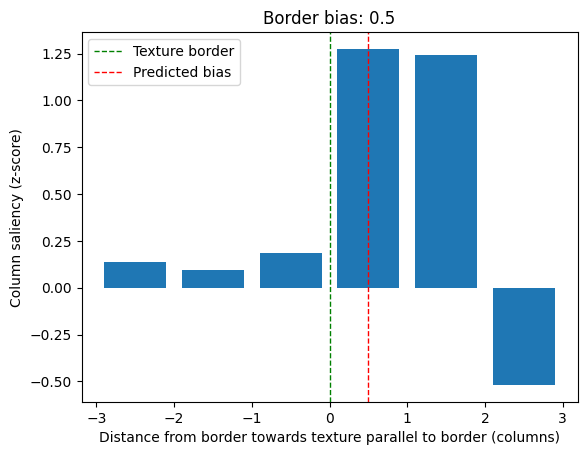

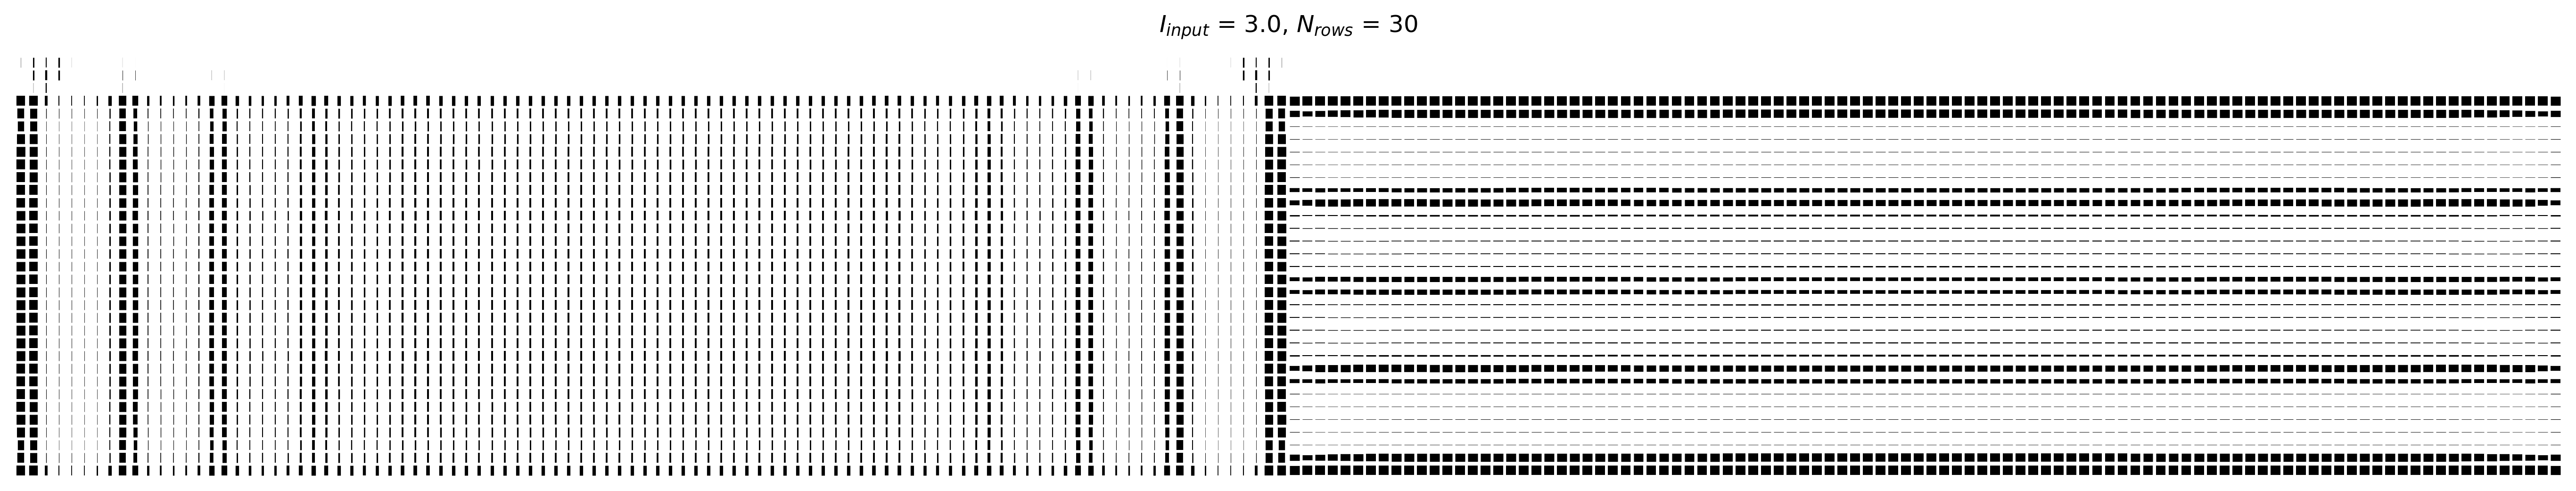

Border saliency: 0.8539267557768045
Border bias: 0.5


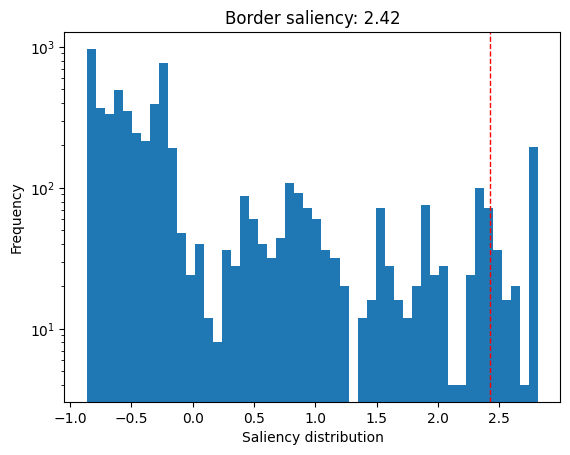

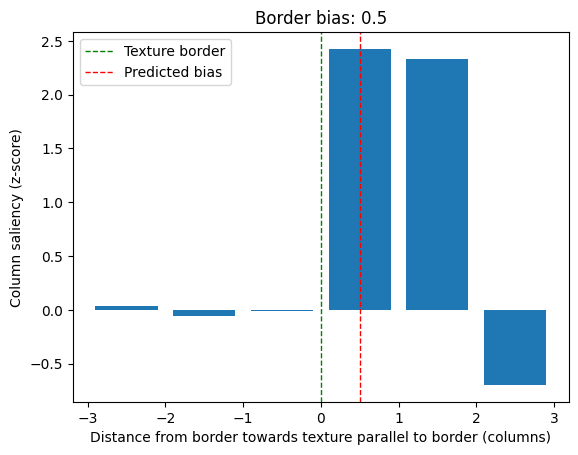

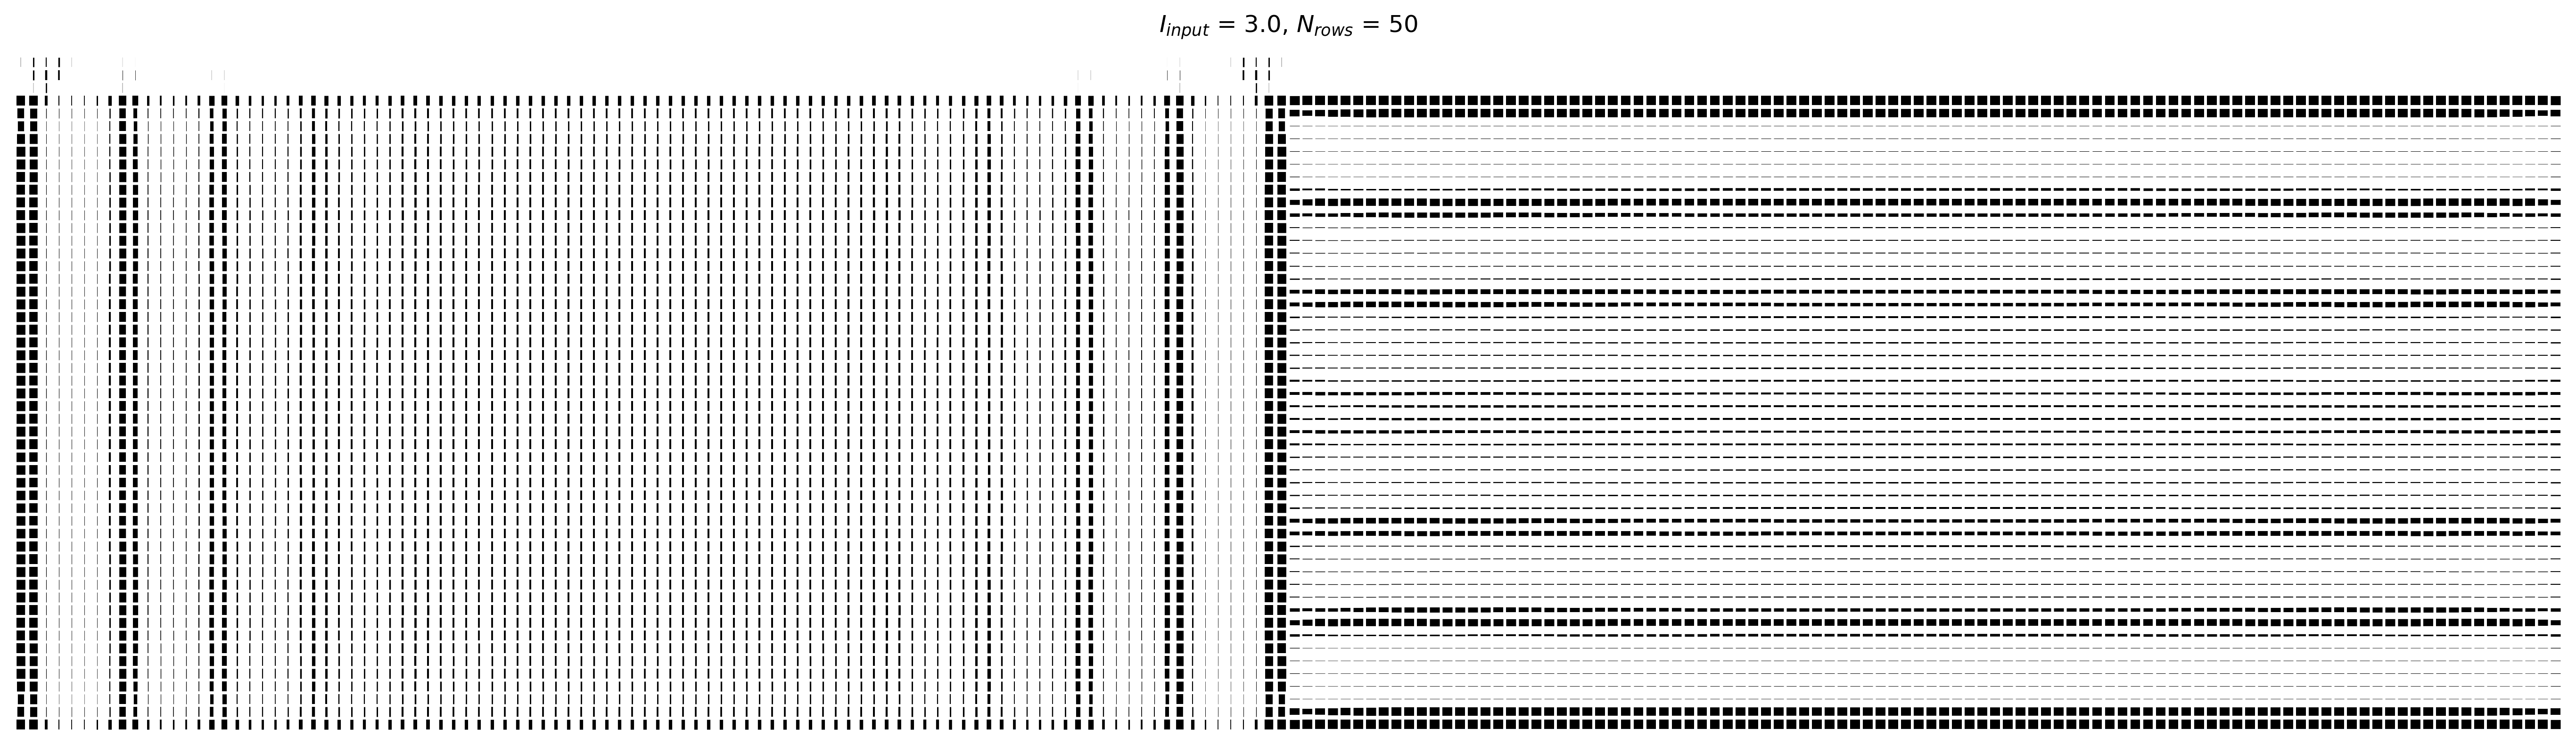

Border saliency: 0.8715237193106575
Border bias: 0.5


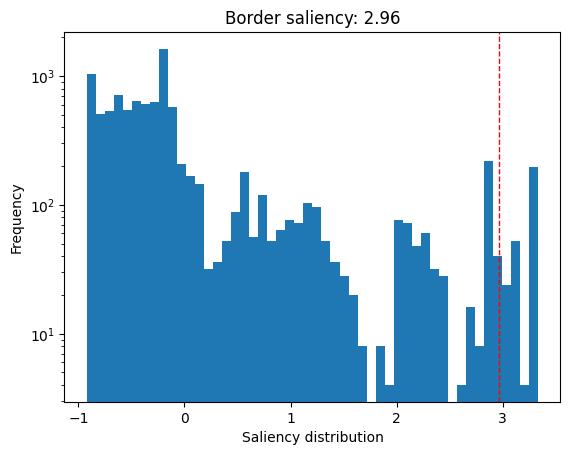

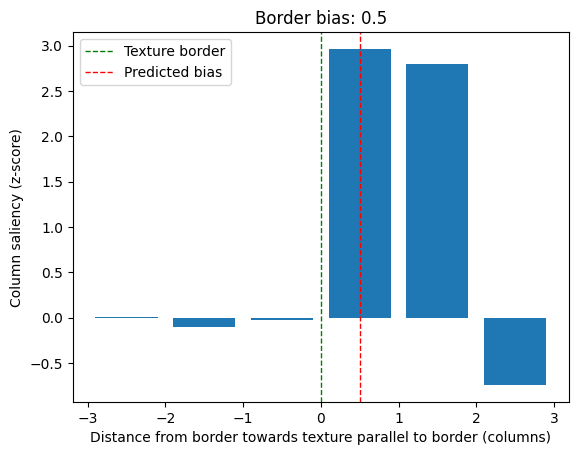

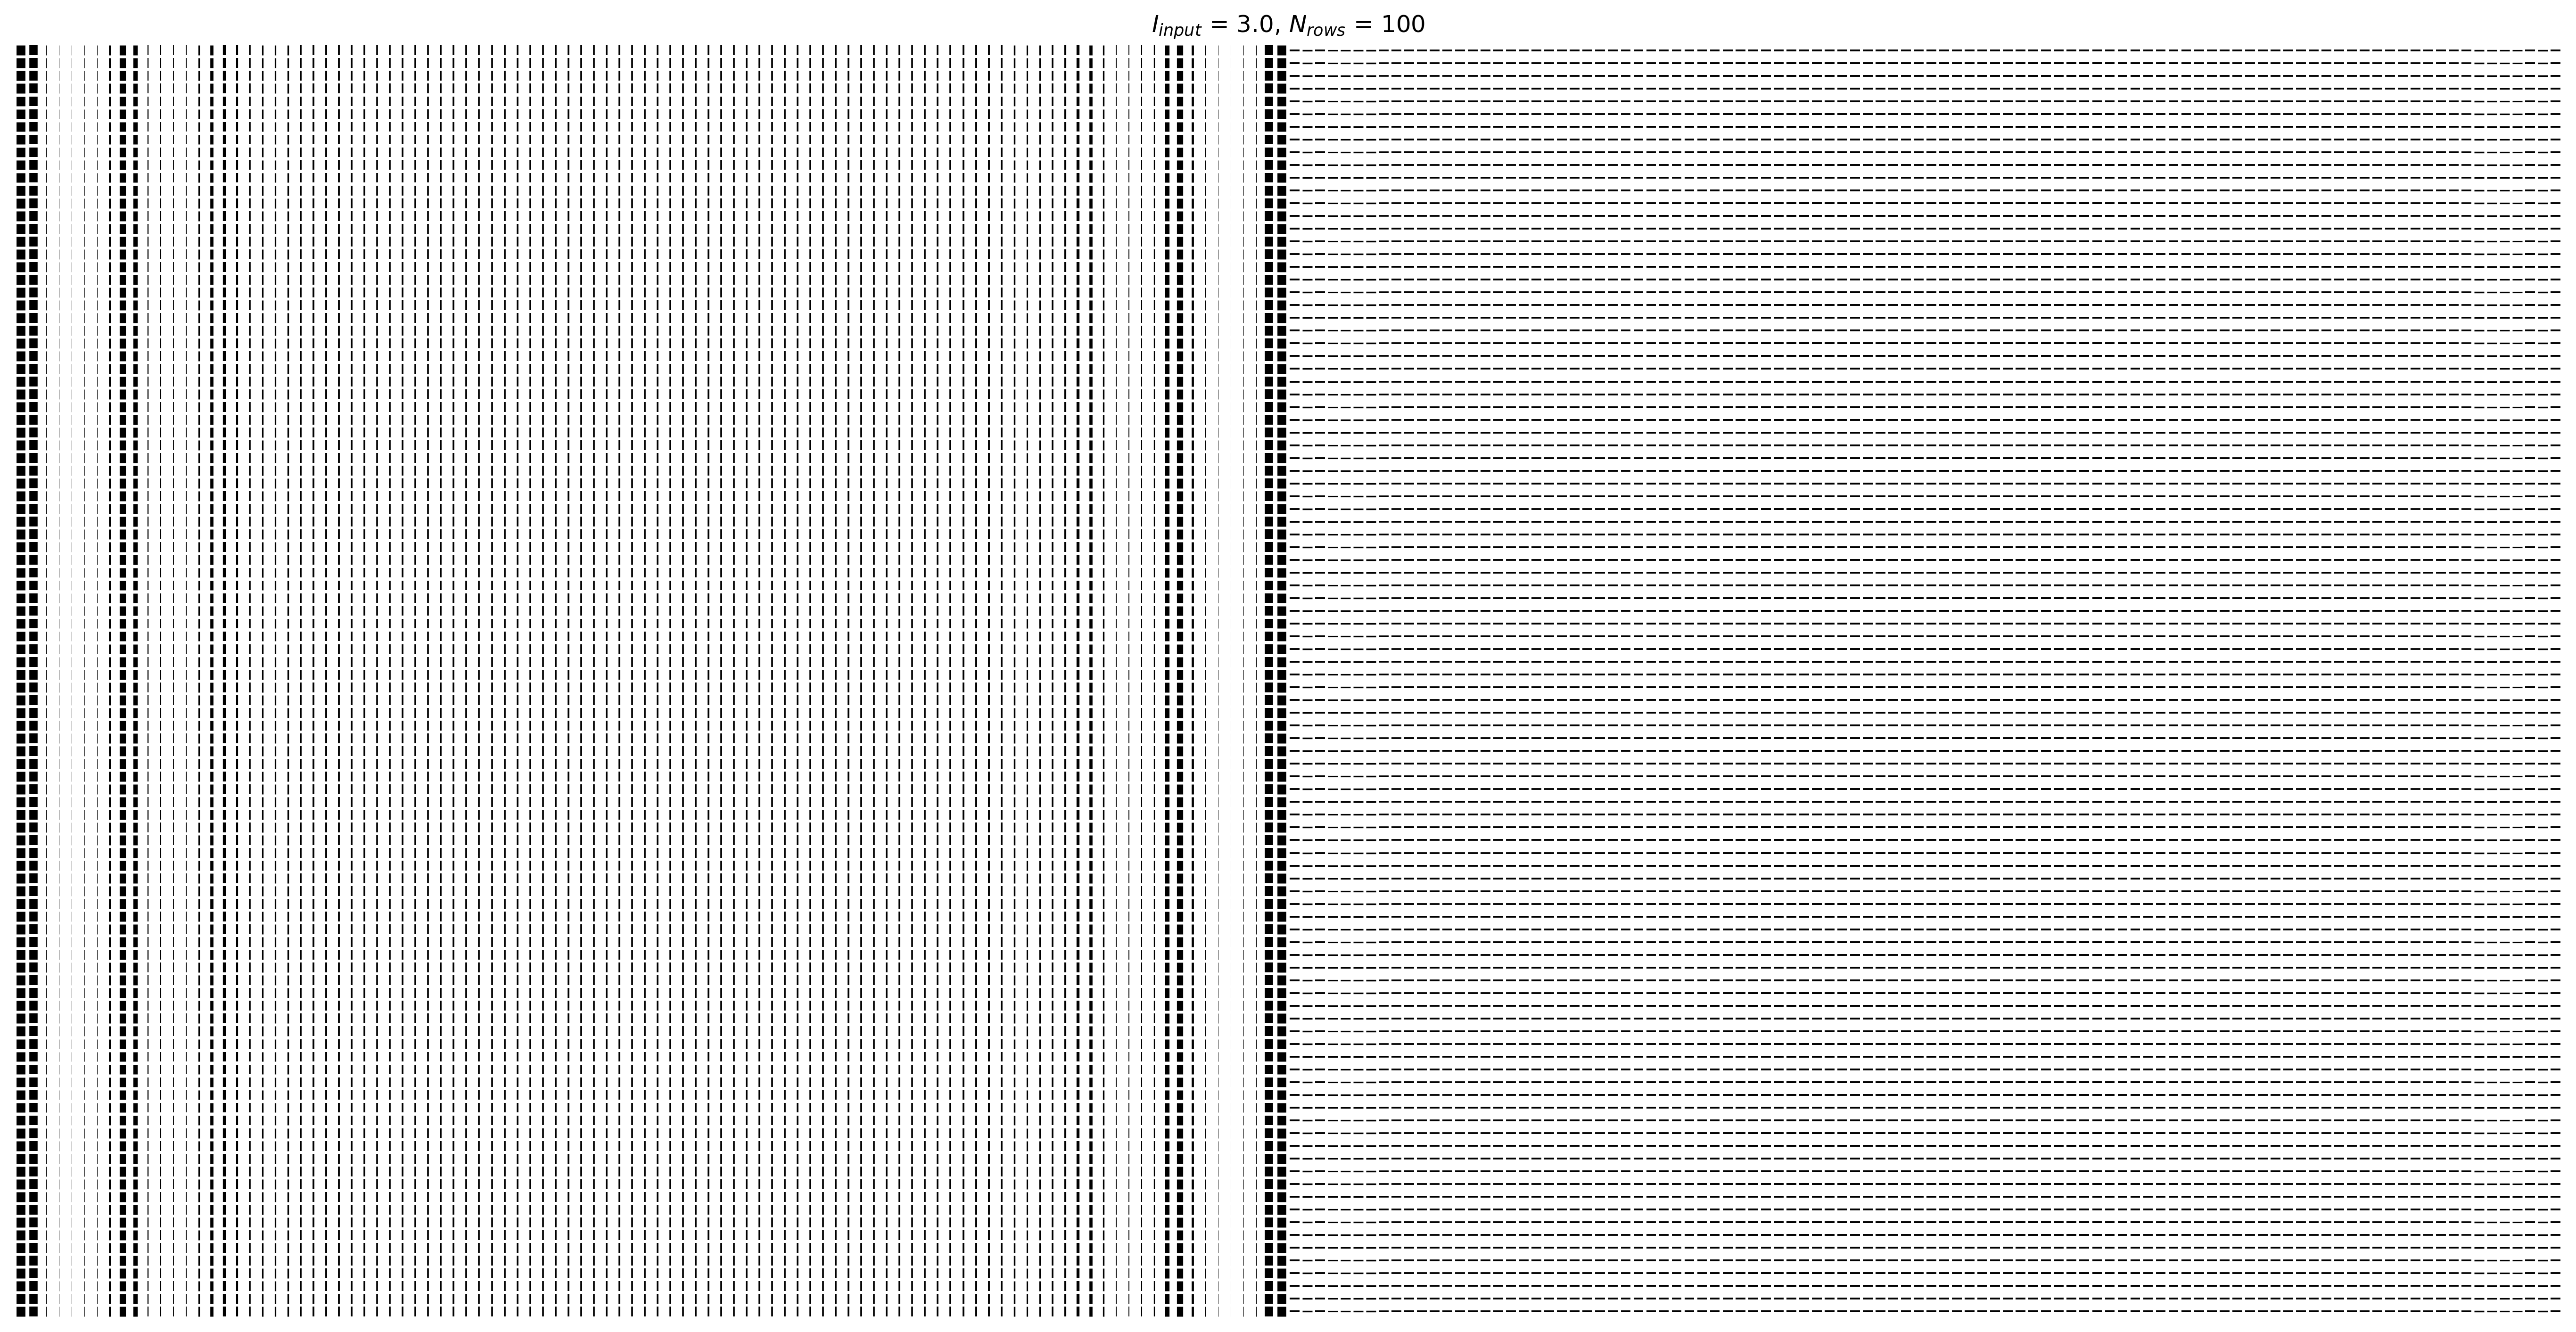

Border saliency: 0.9024775763336613
Border bias: 0.5


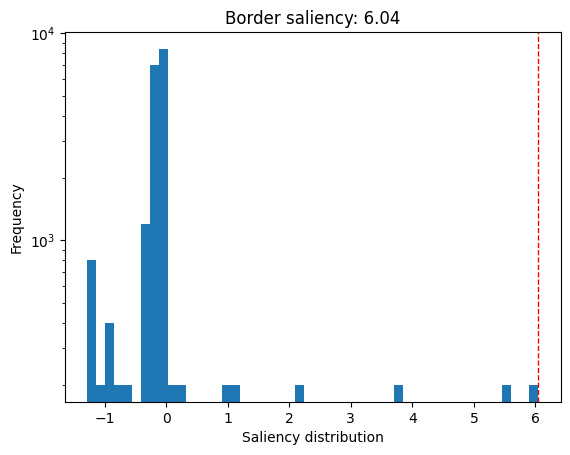

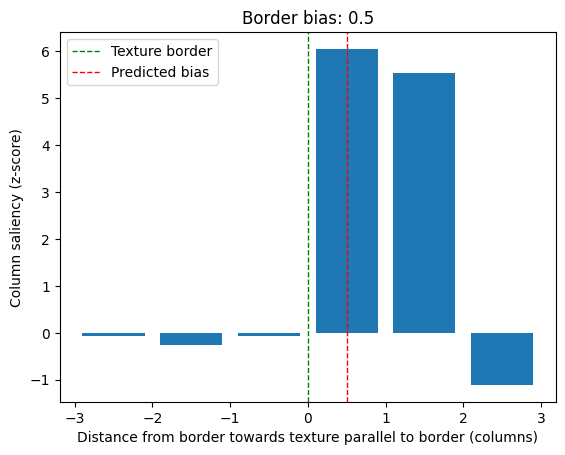

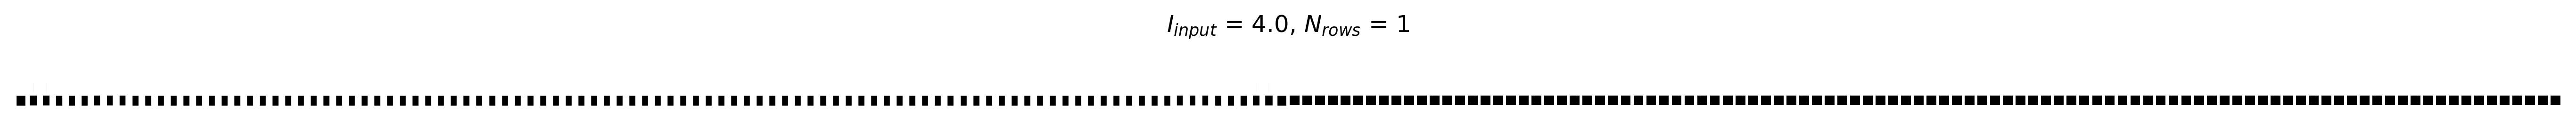

Border saliency: 0.9632397862300836
Border bias: -2.5


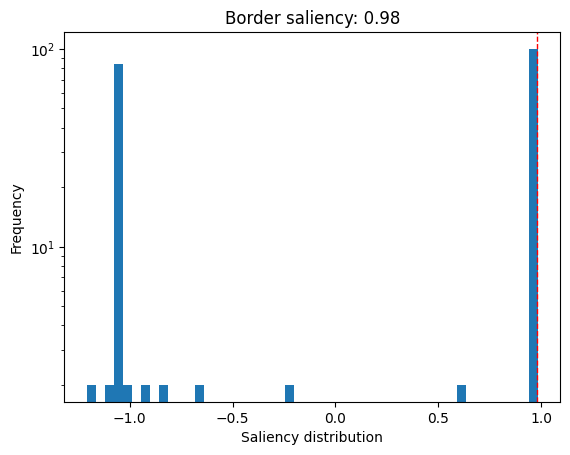

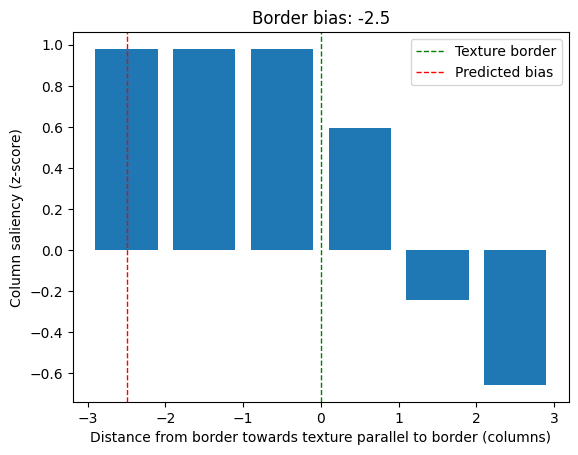

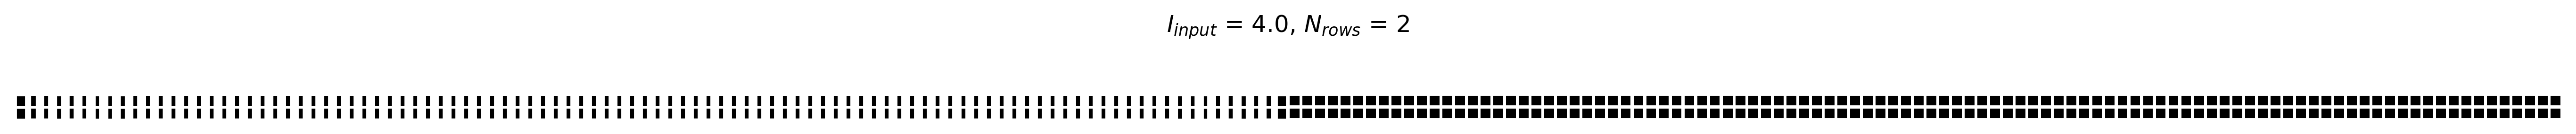

Border saliency: 0.9635619400472198
Border bias: -2.5


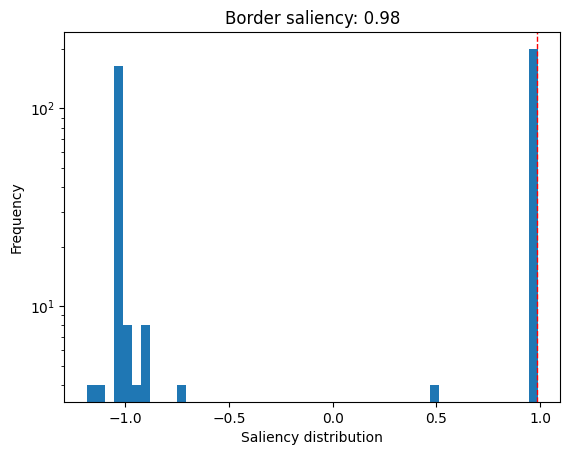

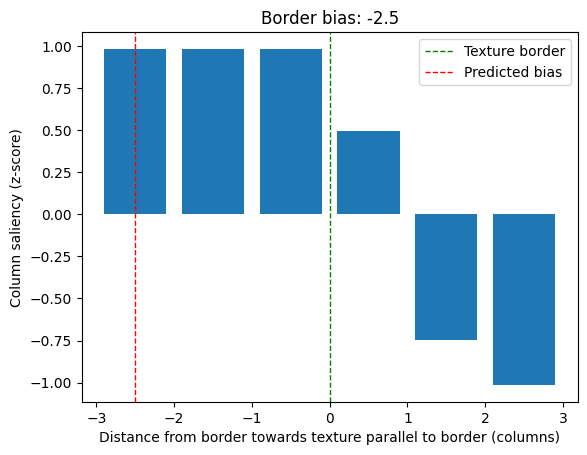

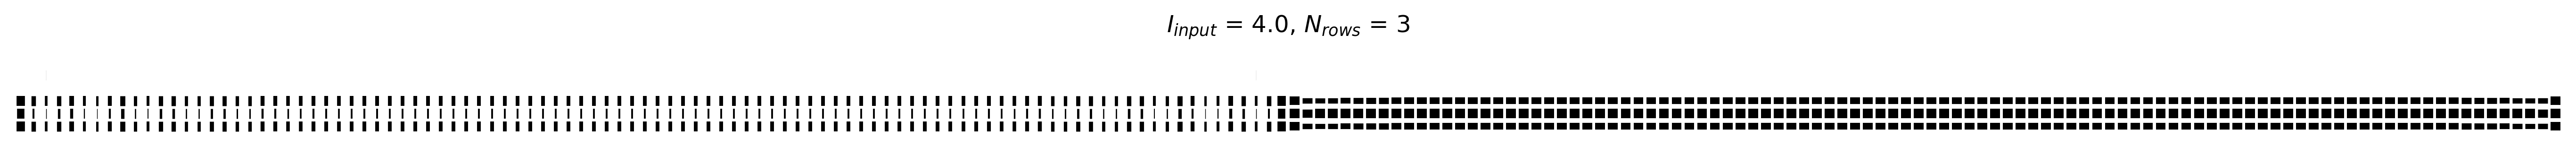

Border saliency: 0.8976647907120551
Border bias: -0.5


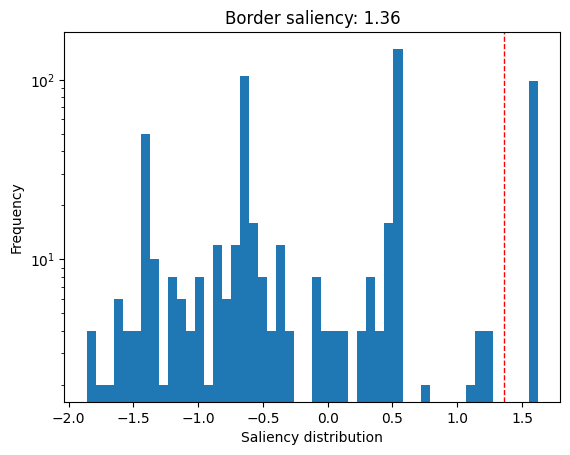

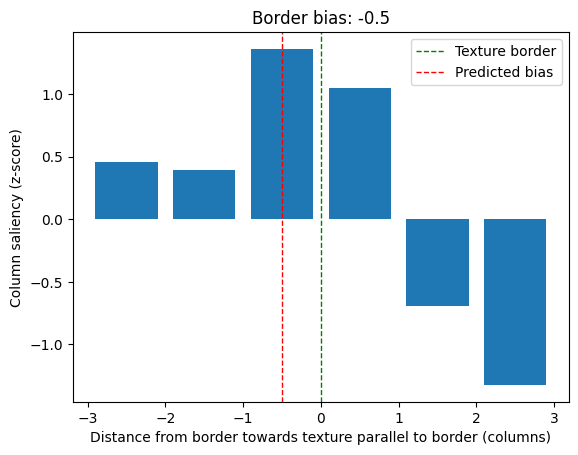

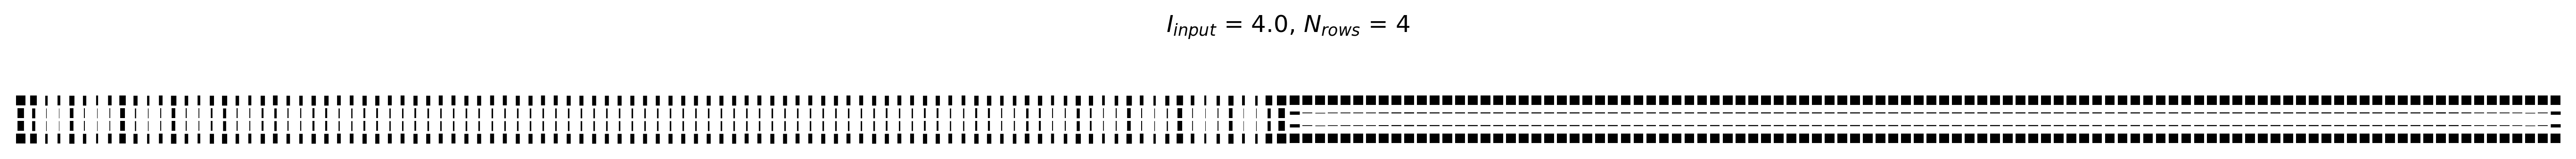

Border saliency: 0.8101815768705938
Border bias: 0.5


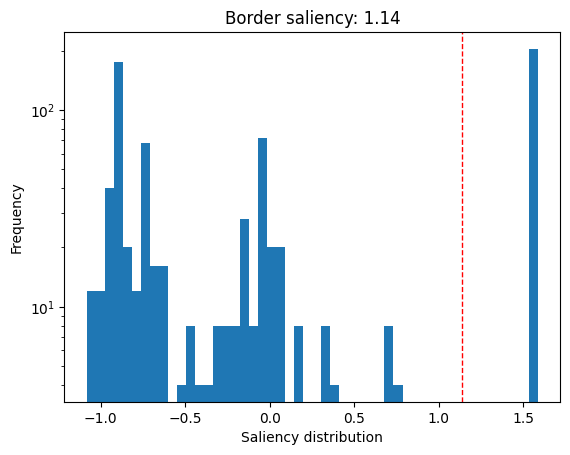

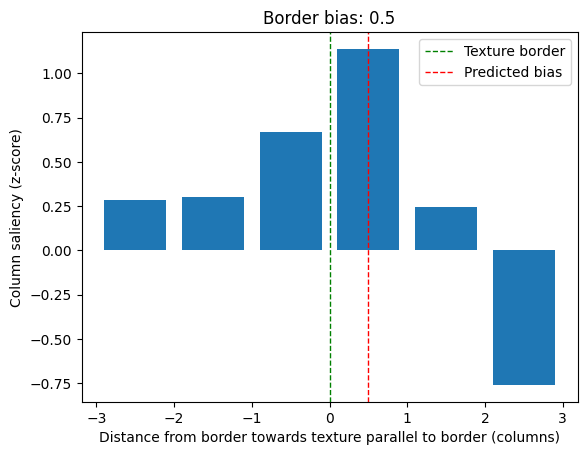

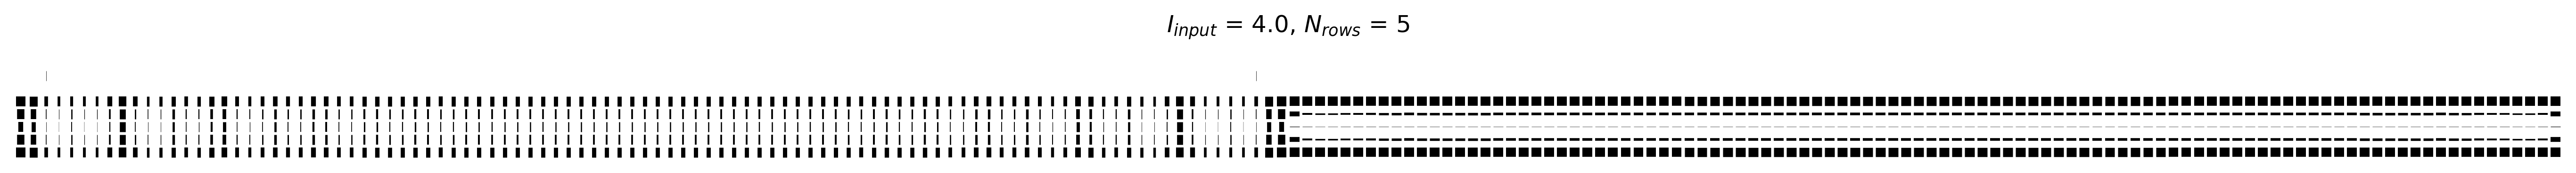

Border saliency: 0.7819250792513069
Border bias: 0.5


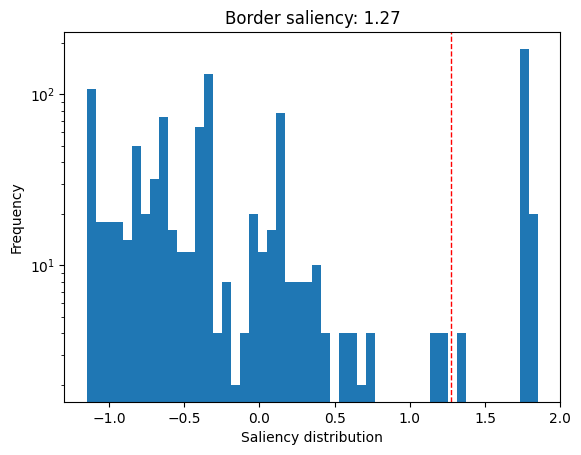

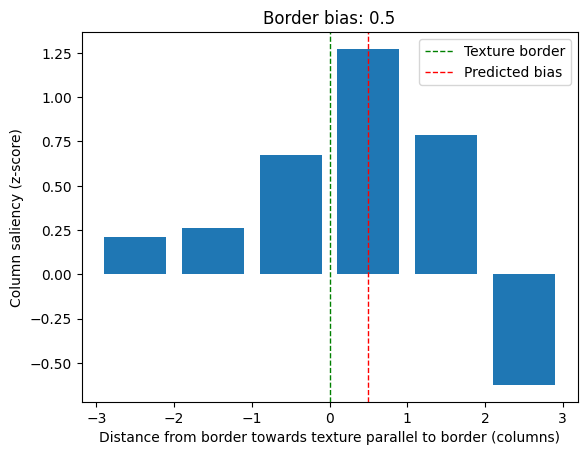

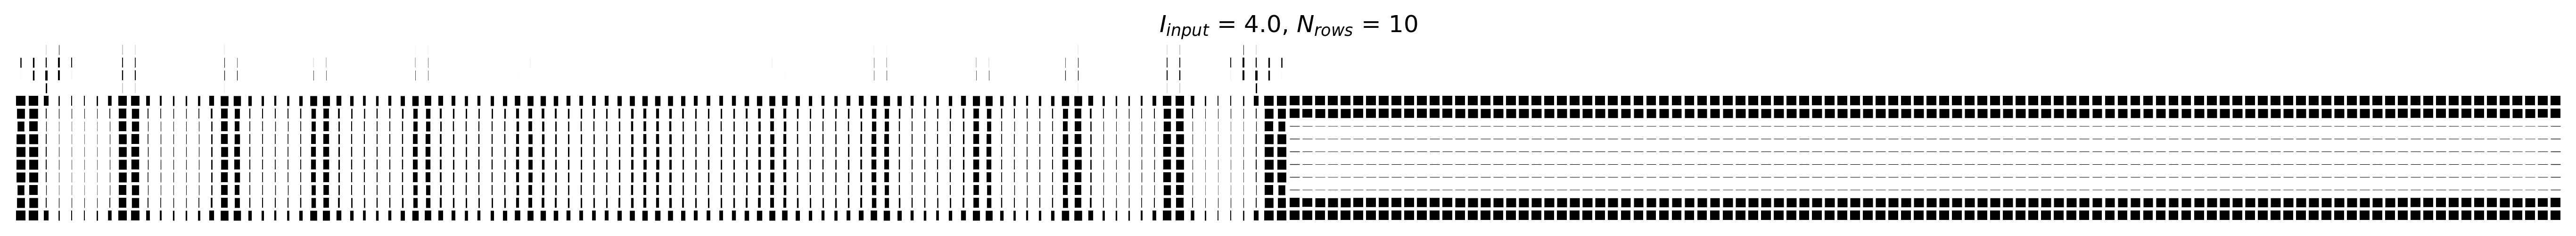

Border saliency: 0.9069513818066935
Border bias: 1.5


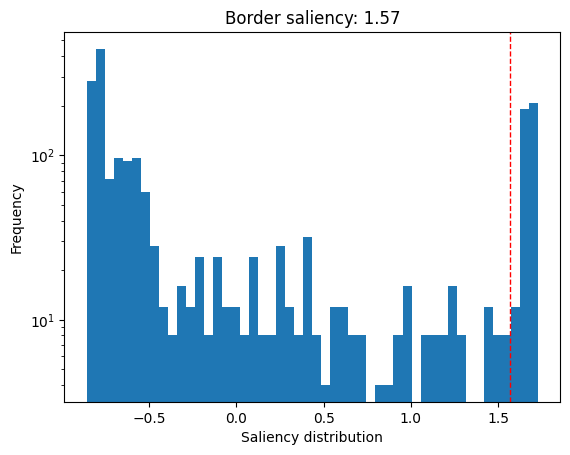

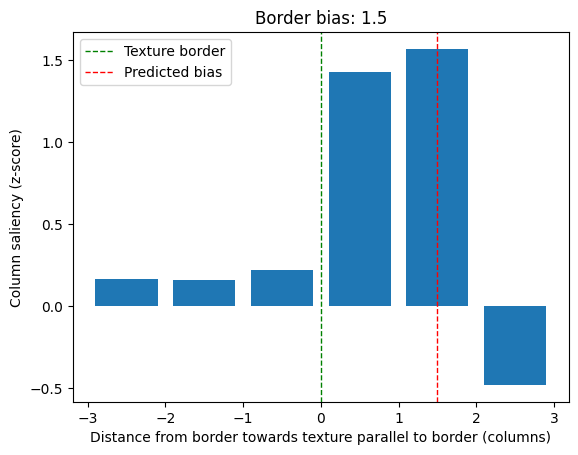

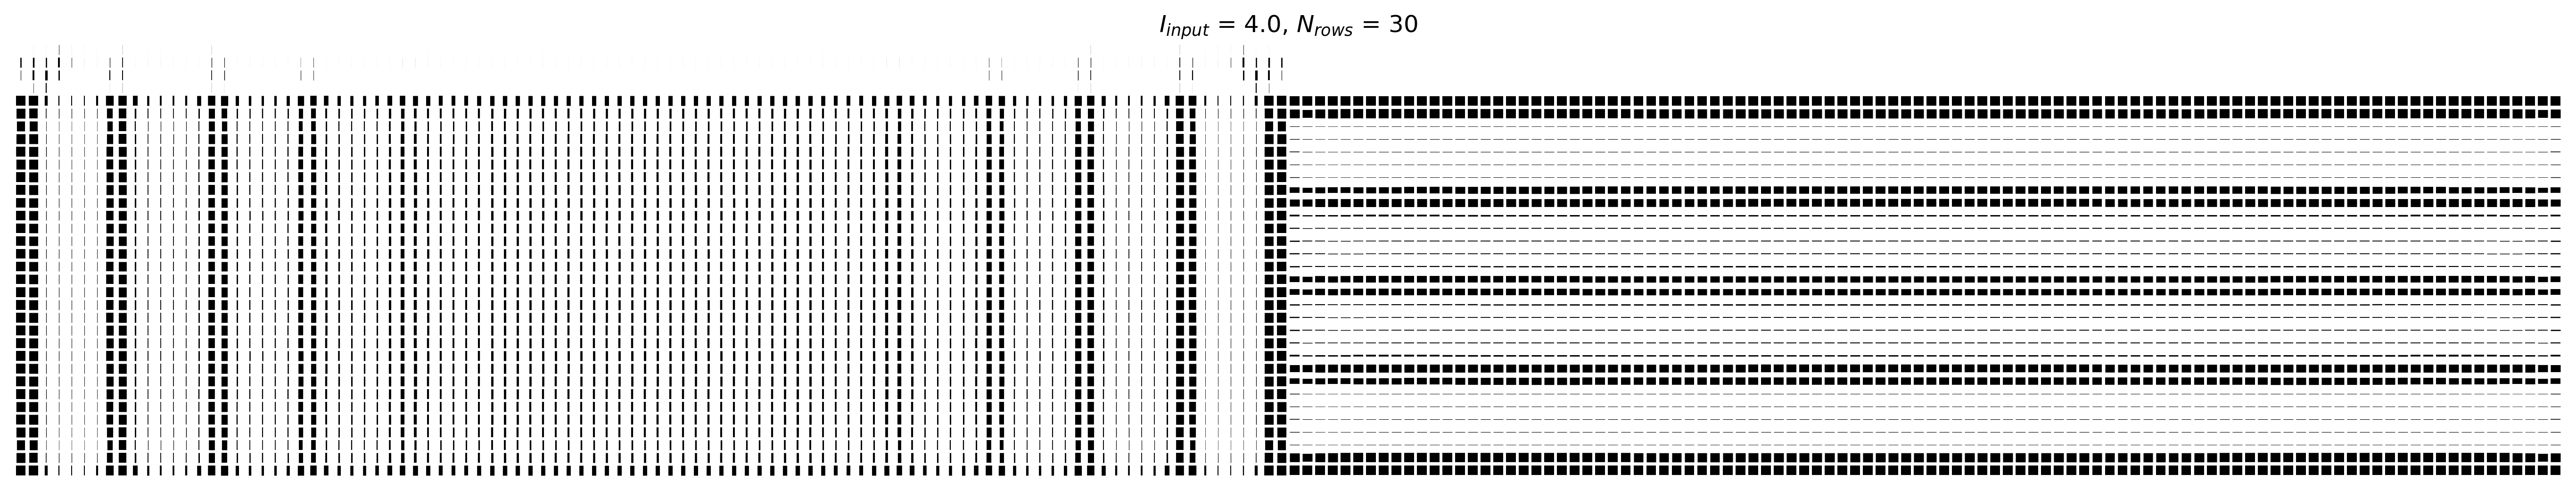

Border saliency: 0.9370533188938655
Border bias: 0.5


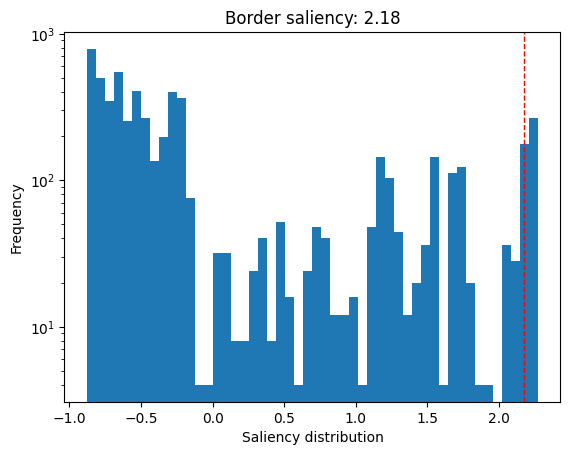

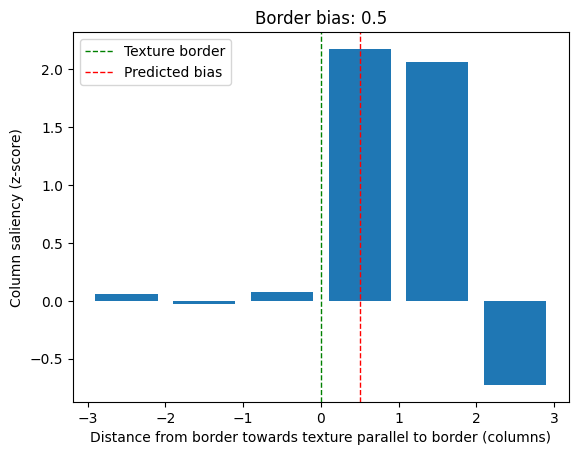

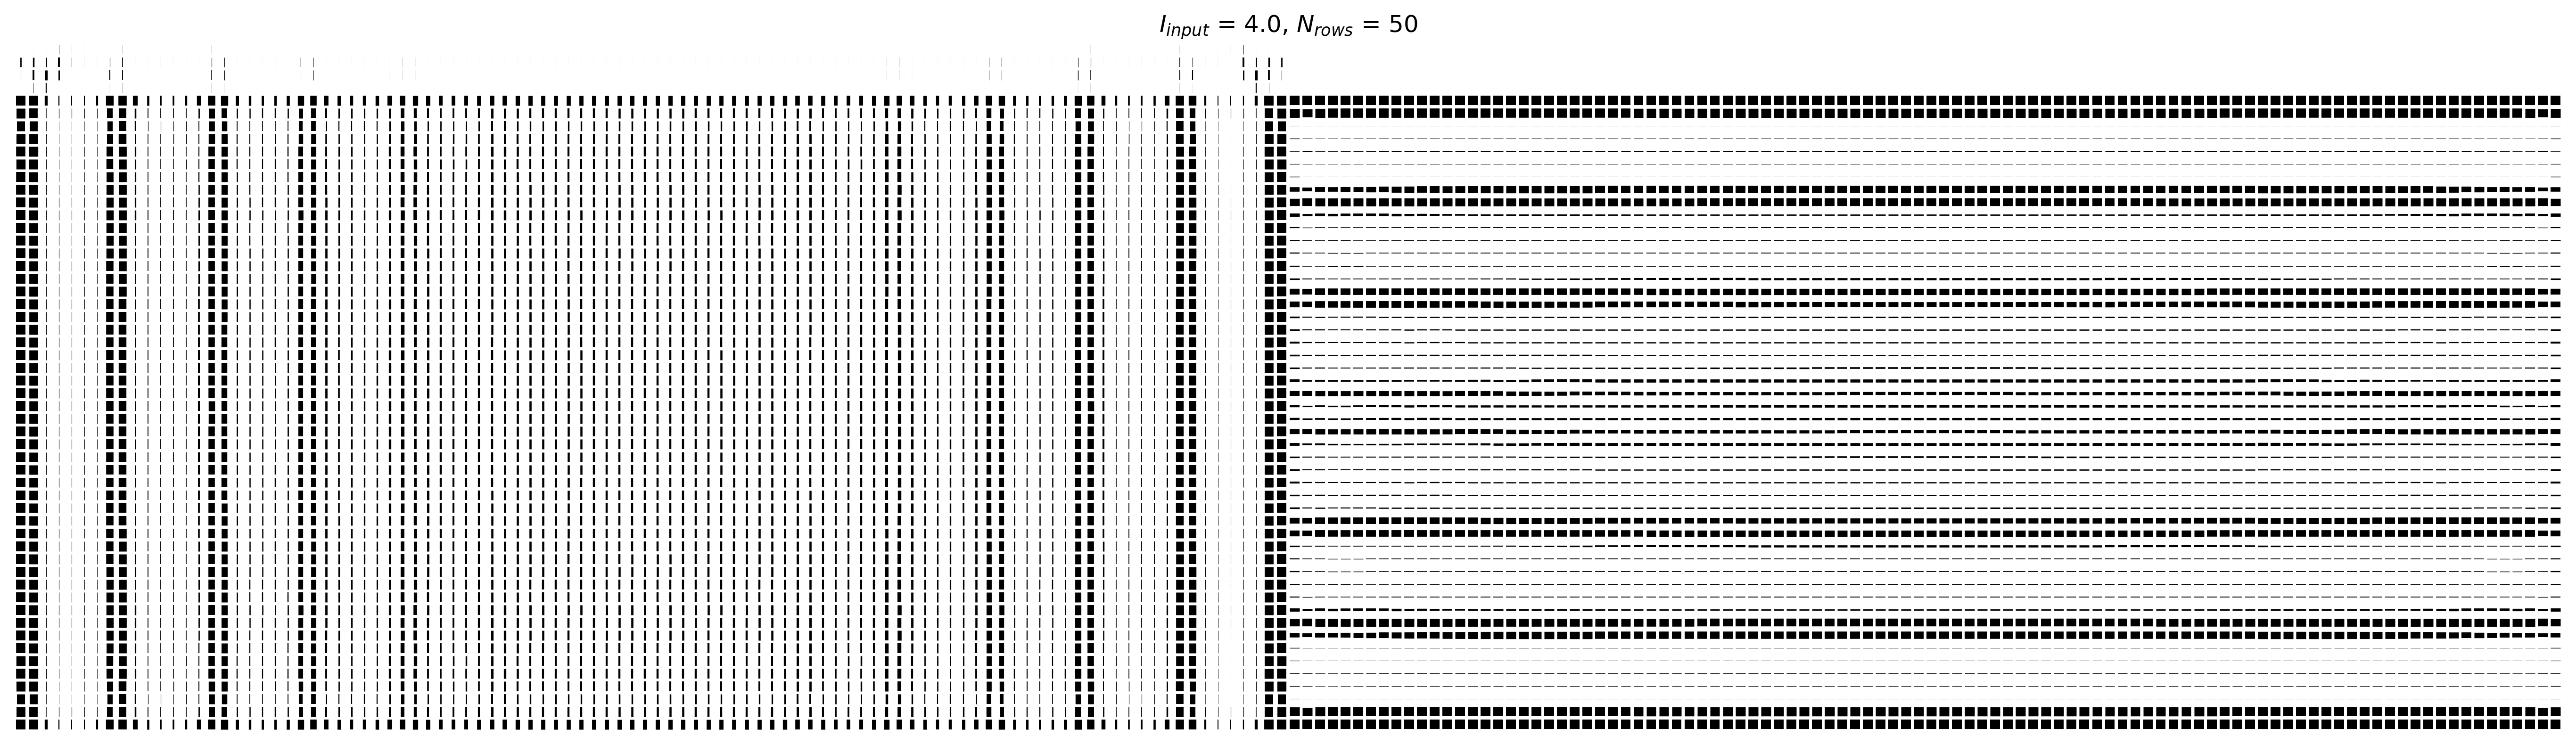

Border saliency: 0.9448566804681664
Border bias: 0.5


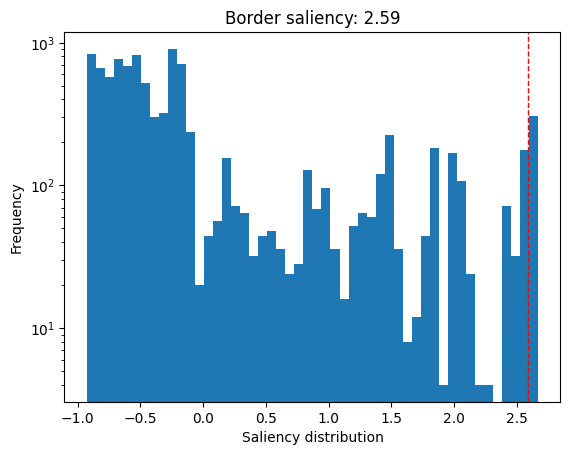

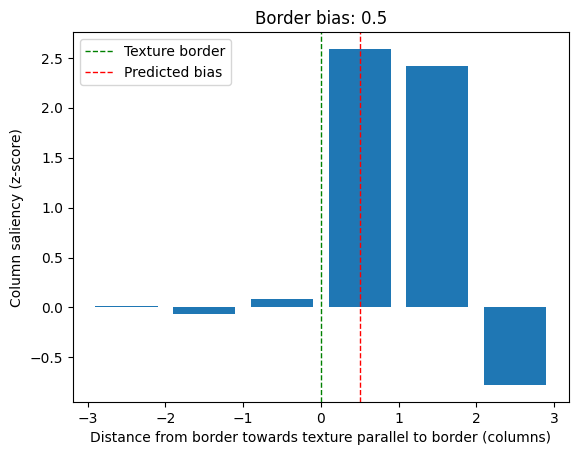

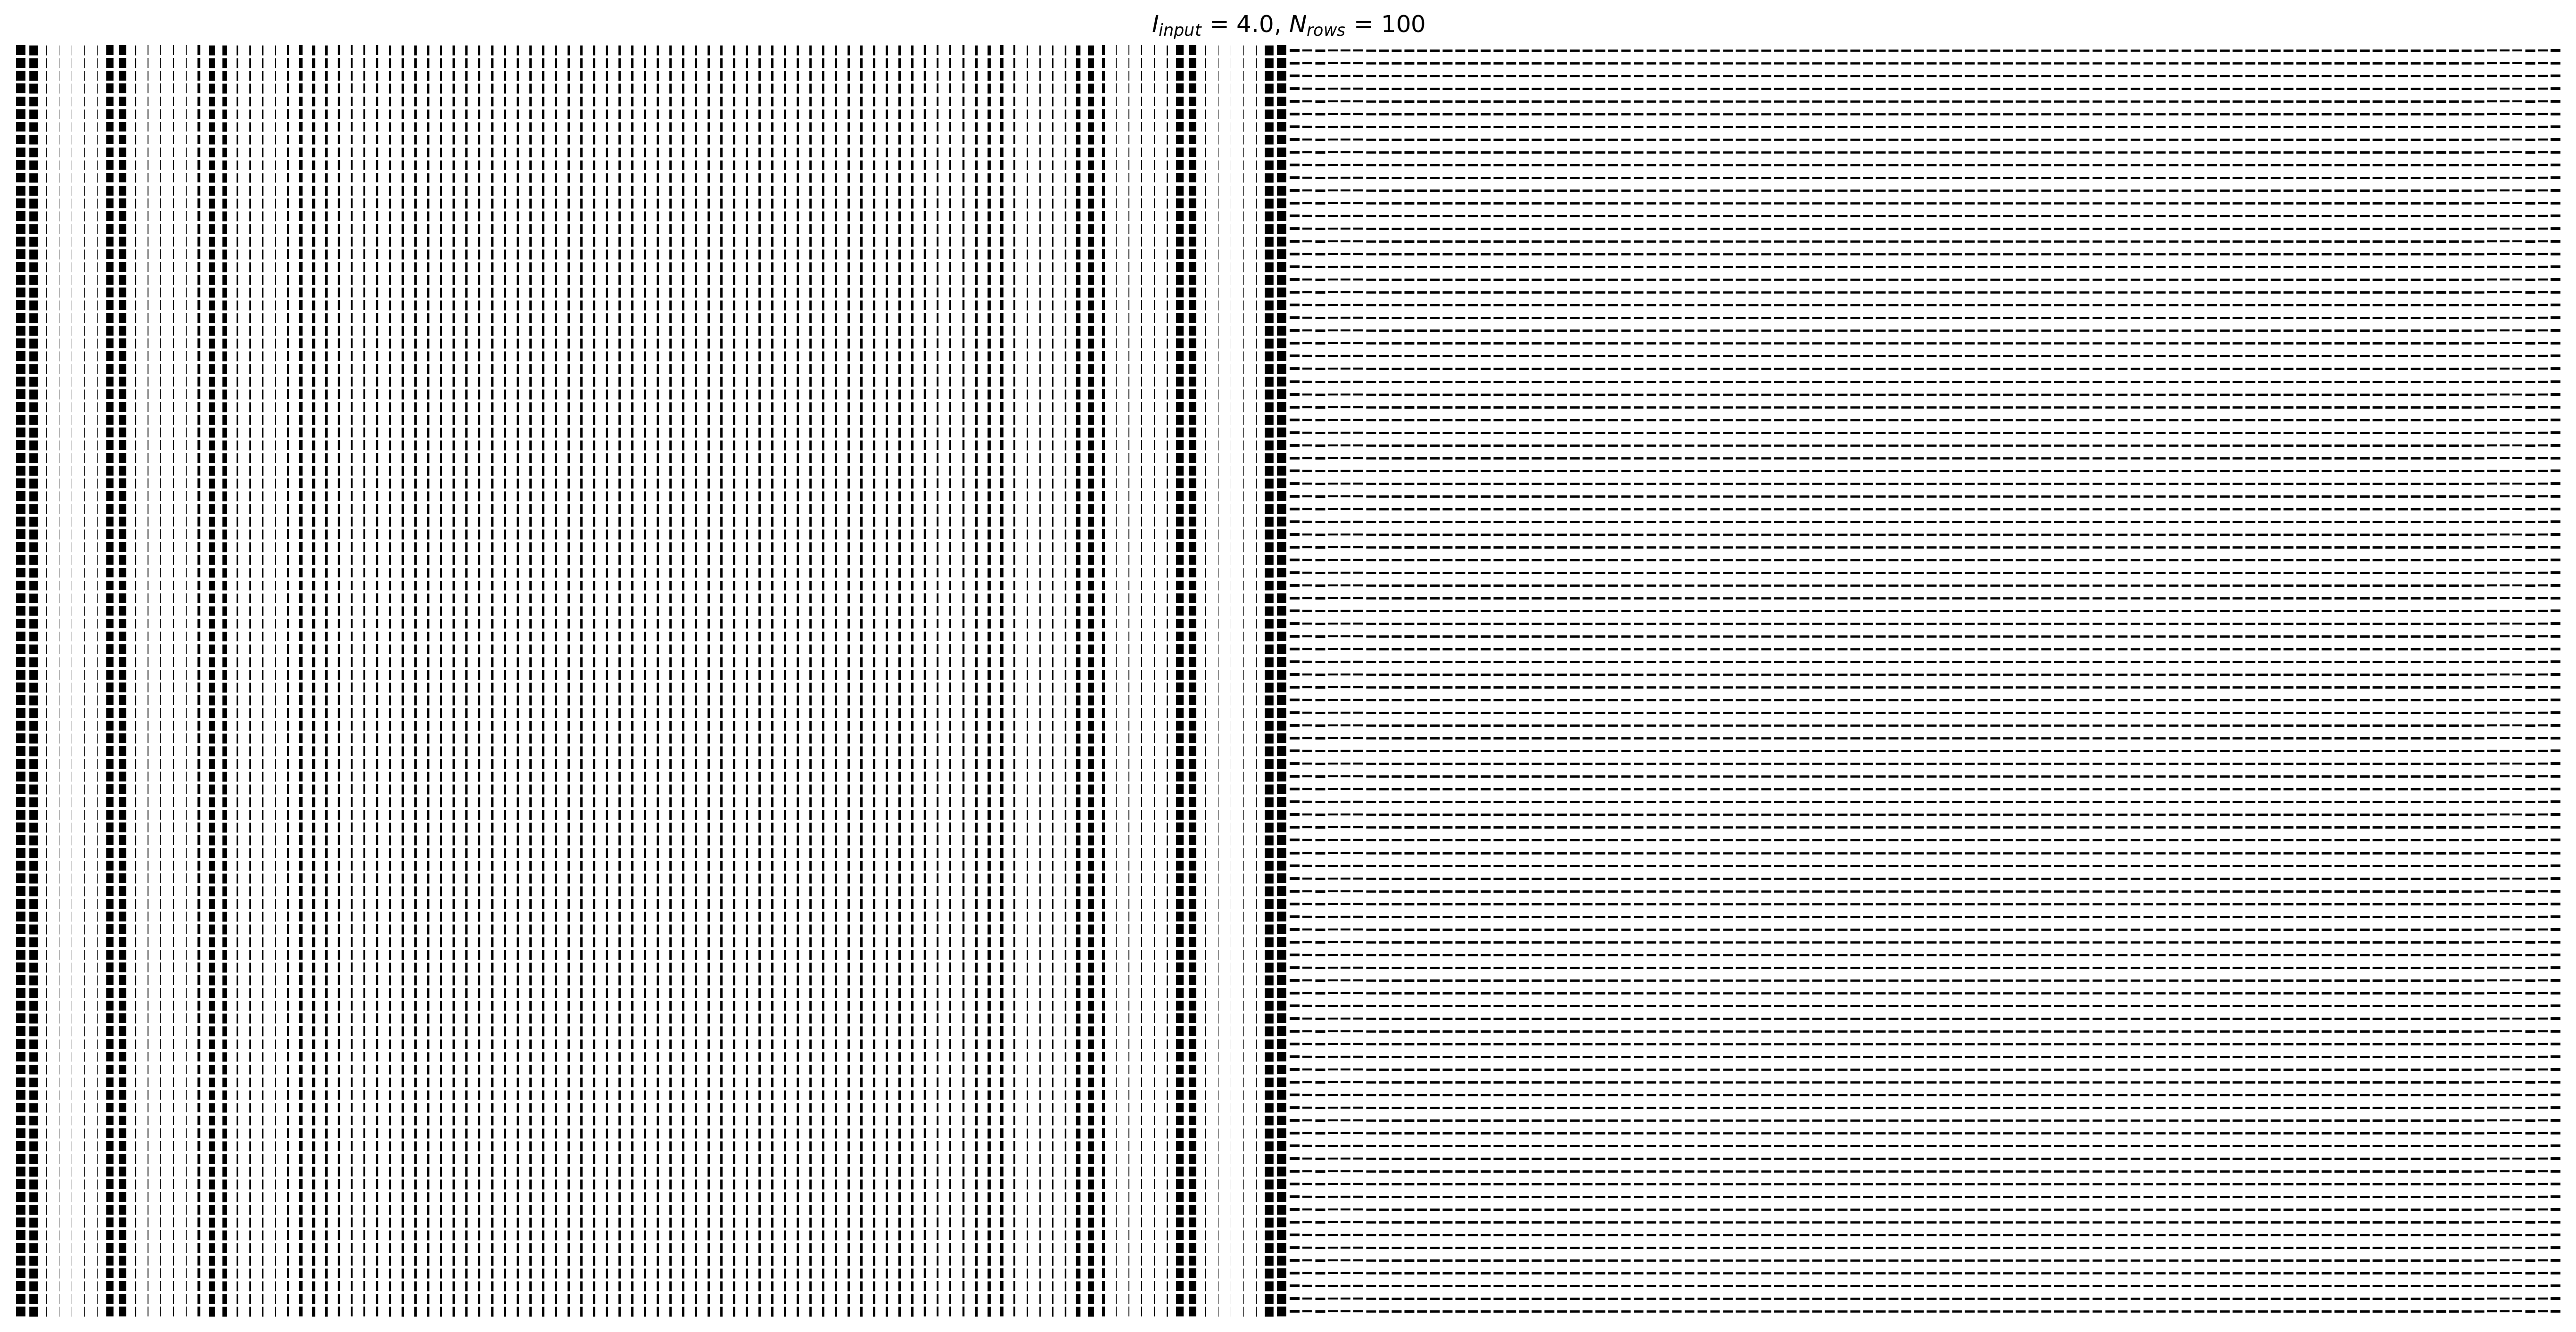

Border saliency: 0.9572127175435792
Border bias: 0.5


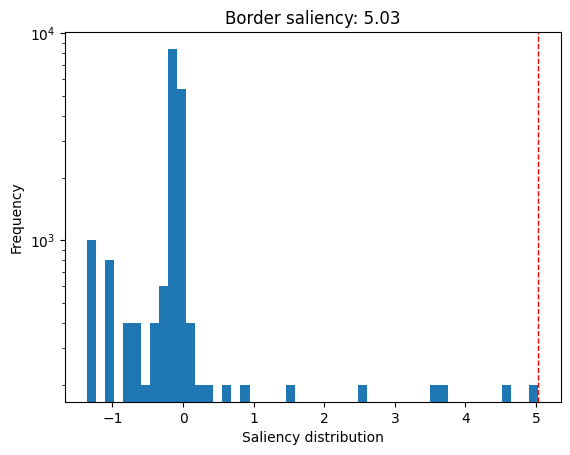

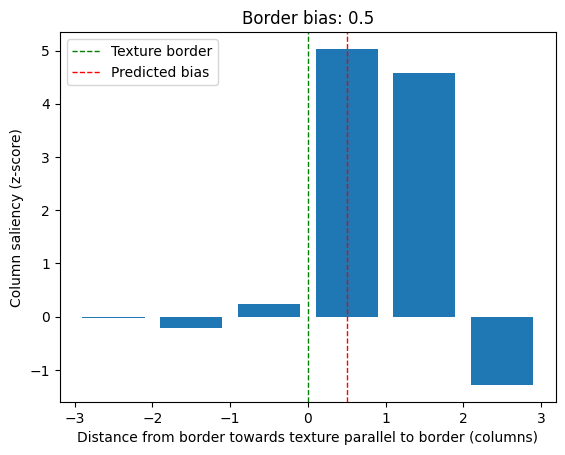

In [6]:
N_y = 100
N_x = 200
N_col = N_x
orientation = 0.0000
n_neighbors = 3

N_rows = []
border_saliencies = {}
border_biases = {}

for key in saliency_maps.keys():
    saliency_map = saliency_maps[key]

    N_row = int(key.split("_")[1][4:])
    I_input = float(key.split("_")[3][6:])

    A, C = stimulus(N_row = N_row, N_col = N_col, N_x = N_x, N_y = N_y, I_input=I_input, orientation = orientation)
    
    A_plot = A[:N_row + 4, 0:N_col + 4]
    smap_plot = saliency_map[:N_row + 4, 0:N_col + 4]
    visualize_output(A_plot,  5 * smap_plot, verbose=False, dpi = 300)
    plt.title(r"$I_{input}$ = " + f"{I_input}, " + r"$N_{rows}$ = " + f"{N_row}")
    plt.show()

    saliency_map_of_texture = saliency_map[:N_row, :N_col]
    border_saliency, border_bias = border_saliency_and_bias_2(saliency_map_of_texture, n_neighbors = n_neighbors, verbose=True)

    if N_row not in N_rows:
        N_rows.append(N_row)
    
    if I_input not in border_saliencies:
        border_saliencies[I_input] = []
        border_biases[I_input] = []
    border_saliencies[I_input].append(border_saliency)
    border_biases[I_input].append(border_bias)



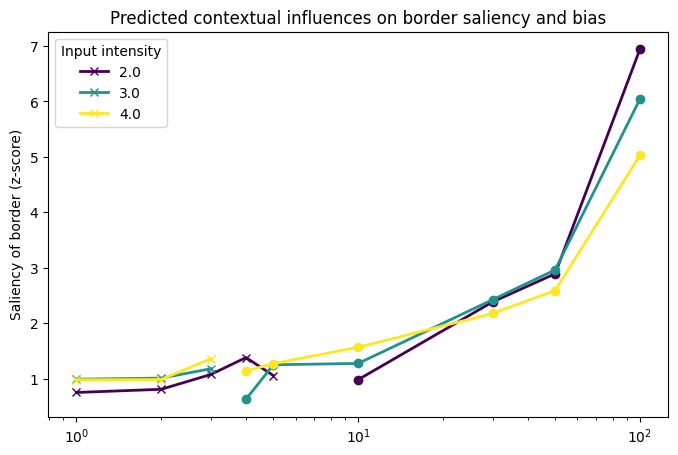

In [5]:
plt.figure(figsize=(8, 5))
markers = {"left": "x", "right": "o"}
colors = plt.cm.viridis(np.linspace(0, 1, len(border_saliencies.keys())))

for color, I_input in zip(colors, border_saliencies.keys()):
    border_saliency = border_saliencies[I_input]
    border_bias = border_biases[I_input]
    
    bias_neg_mask = np.array(border_bias) < 0
    N_rows_neg = np.array(N_rows)[bias_neg_mask]
    border_saliency_neg = np.array(border_saliency)[bias_neg_mask]
    plt.plot(N_rows_neg, border_saliency_neg, marker=markers["left"], color=color, linewidth=2, label=f"{I_input}")

    bias_pos_mask = np.array(border_bias) >= 0
    N_rows_pos = np.array(N_rows)[bias_pos_mask]
    border_saliency_pos = np.array(border_saliency)[bias_pos_mask]
    plt.plot(N_rows_pos, border_saliency_pos, marker=markers["right"], color=color, linewidth=2)
    
plt.xscale('log')
plt.ylabel("Saliency of border (z-score)")
plt.legend(title="Input intensity")
plt.title("Predicted contextual influences on border saliency and bias")
plt.show()

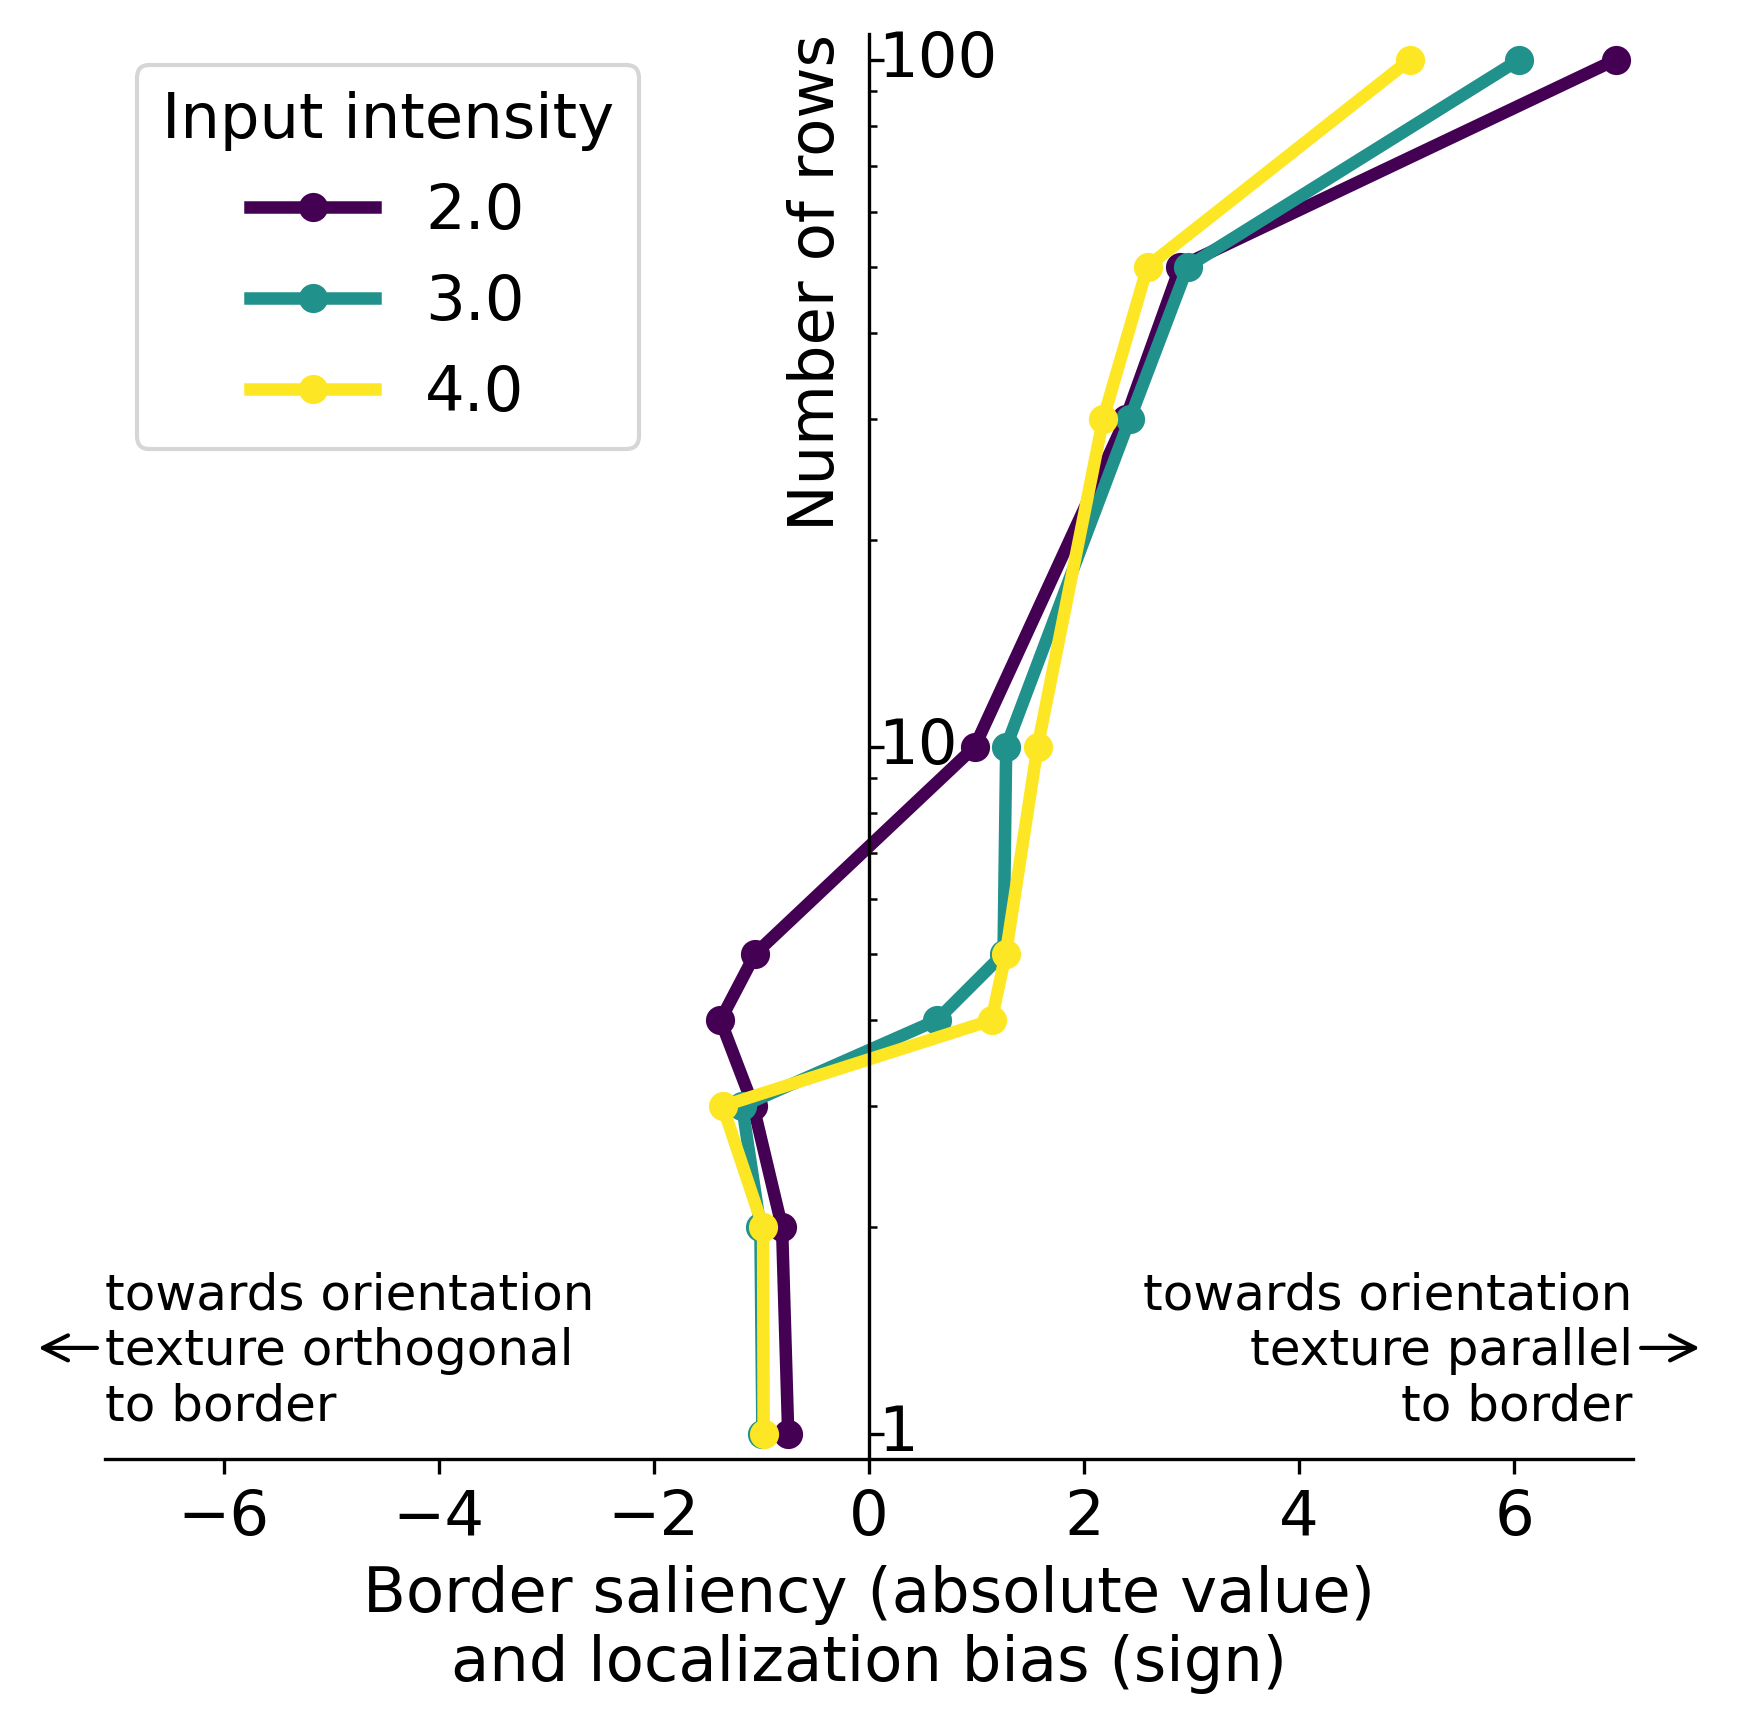

In [8]:
choose_input = None
plt.figure(figsize=(6, 6), dpi = 300)
plt.rcParams.update({'font.size': 15})
colors = plt.cm.viridis(np.linspace(0, 1, len(border_saliencies.keys())))

for idx, (color, I_input) in enumerate(zip(colors, border_saliencies.keys())):
    if choose_input is not None:
        if idx != choose_input:
            continue

    border_saliency = np.array(border_saliencies[I_input])
    assert np.all(border_saliency >= 0), "Border saliency should be non-negative for the plot to work."
    border_bias = np.array(border_biases[I_input])
    
    bias_neg_mask = np.array(border_bias) < 0
    border_saliency_score = border_saliency.copy()
    border_saliency_score[bias_neg_mask] = -border_saliency[bias_neg_mask]
    plt.plot(border_saliency_score, N_rows, marker="o", color=color, linewidth=3, label = f"{I_input}")

# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Move y-axis to cross x-axis at x=0
ax.spines['left'].set_position(('data', 0))
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_tick_params(direction='in')
ax.yaxis.set_tick_params(which='minor', direction='in')
for tick in ax.yaxis.get_major_ticks():
    tick.label1.set_verticalalignment('center')
    tick.label1.set_horizontalalignment('left')
    tick.label1.set_x(0.22)  # Negative moves label inside; adjust as needed
plt.xlim(-7.1, 7.1)
plt.ylim(0.92, 109)
plt.yscale('log')
from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylabel("Number of rows",
            loc="top",        # Position label at the top
            labelpad=2)      # Optional: add padding for better spacing
plt.xlabel("Border saliency (absolute value)\nand localization bias (sign)")
ax.text(
    plt.xlim()[1], 1.1 * plt.ylim()[0],  # x, y coordinates (slightly above axis)
    "towards orientation\ntexture parallel\nto border",
    ha='right', va='bottom', fontsize=12
)
ax.annotate(
    '', 
    xy=(plt.xlim()[1], 1.45 * plt.ylim()[0]),           # Arrow tip (same as text position)
    xytext=(plt.xlim()[1] + 0.7, 1.45 * plt.ylim()[0]),   # Arrow tail (shift right)
    arrowprops=dict(arrowstyle="<-", color='black', lw=1)
)
ax.text(
    plt.xlim()[0], 1.1 * plt.ylim()[0],  # x, y coordinates (slightly above axis)
    "towards orientation\ntexture orthogonal\nto border",
    ha='left', va='bottom', fontsize=12
)
ax.annotate(
    '', 
    xy=(plt.xlim()[0], 1.45 * plt.ylim()[0]),           # Arrow tip (same as text position)
    xytext=(plt.xlim()[0] - 0.7, 1.45 * plt.ylim()[0]),   # Arrow tail (shift right)
    arrowprops=dict(arrowstyle="<-", color='black', lw=1)
)
plt.legend(title="Input intensity")
# plt.title("Predicted contextual influences\non border saliency and bias")
plt.tight_layout()
plt.show()

# For presentation

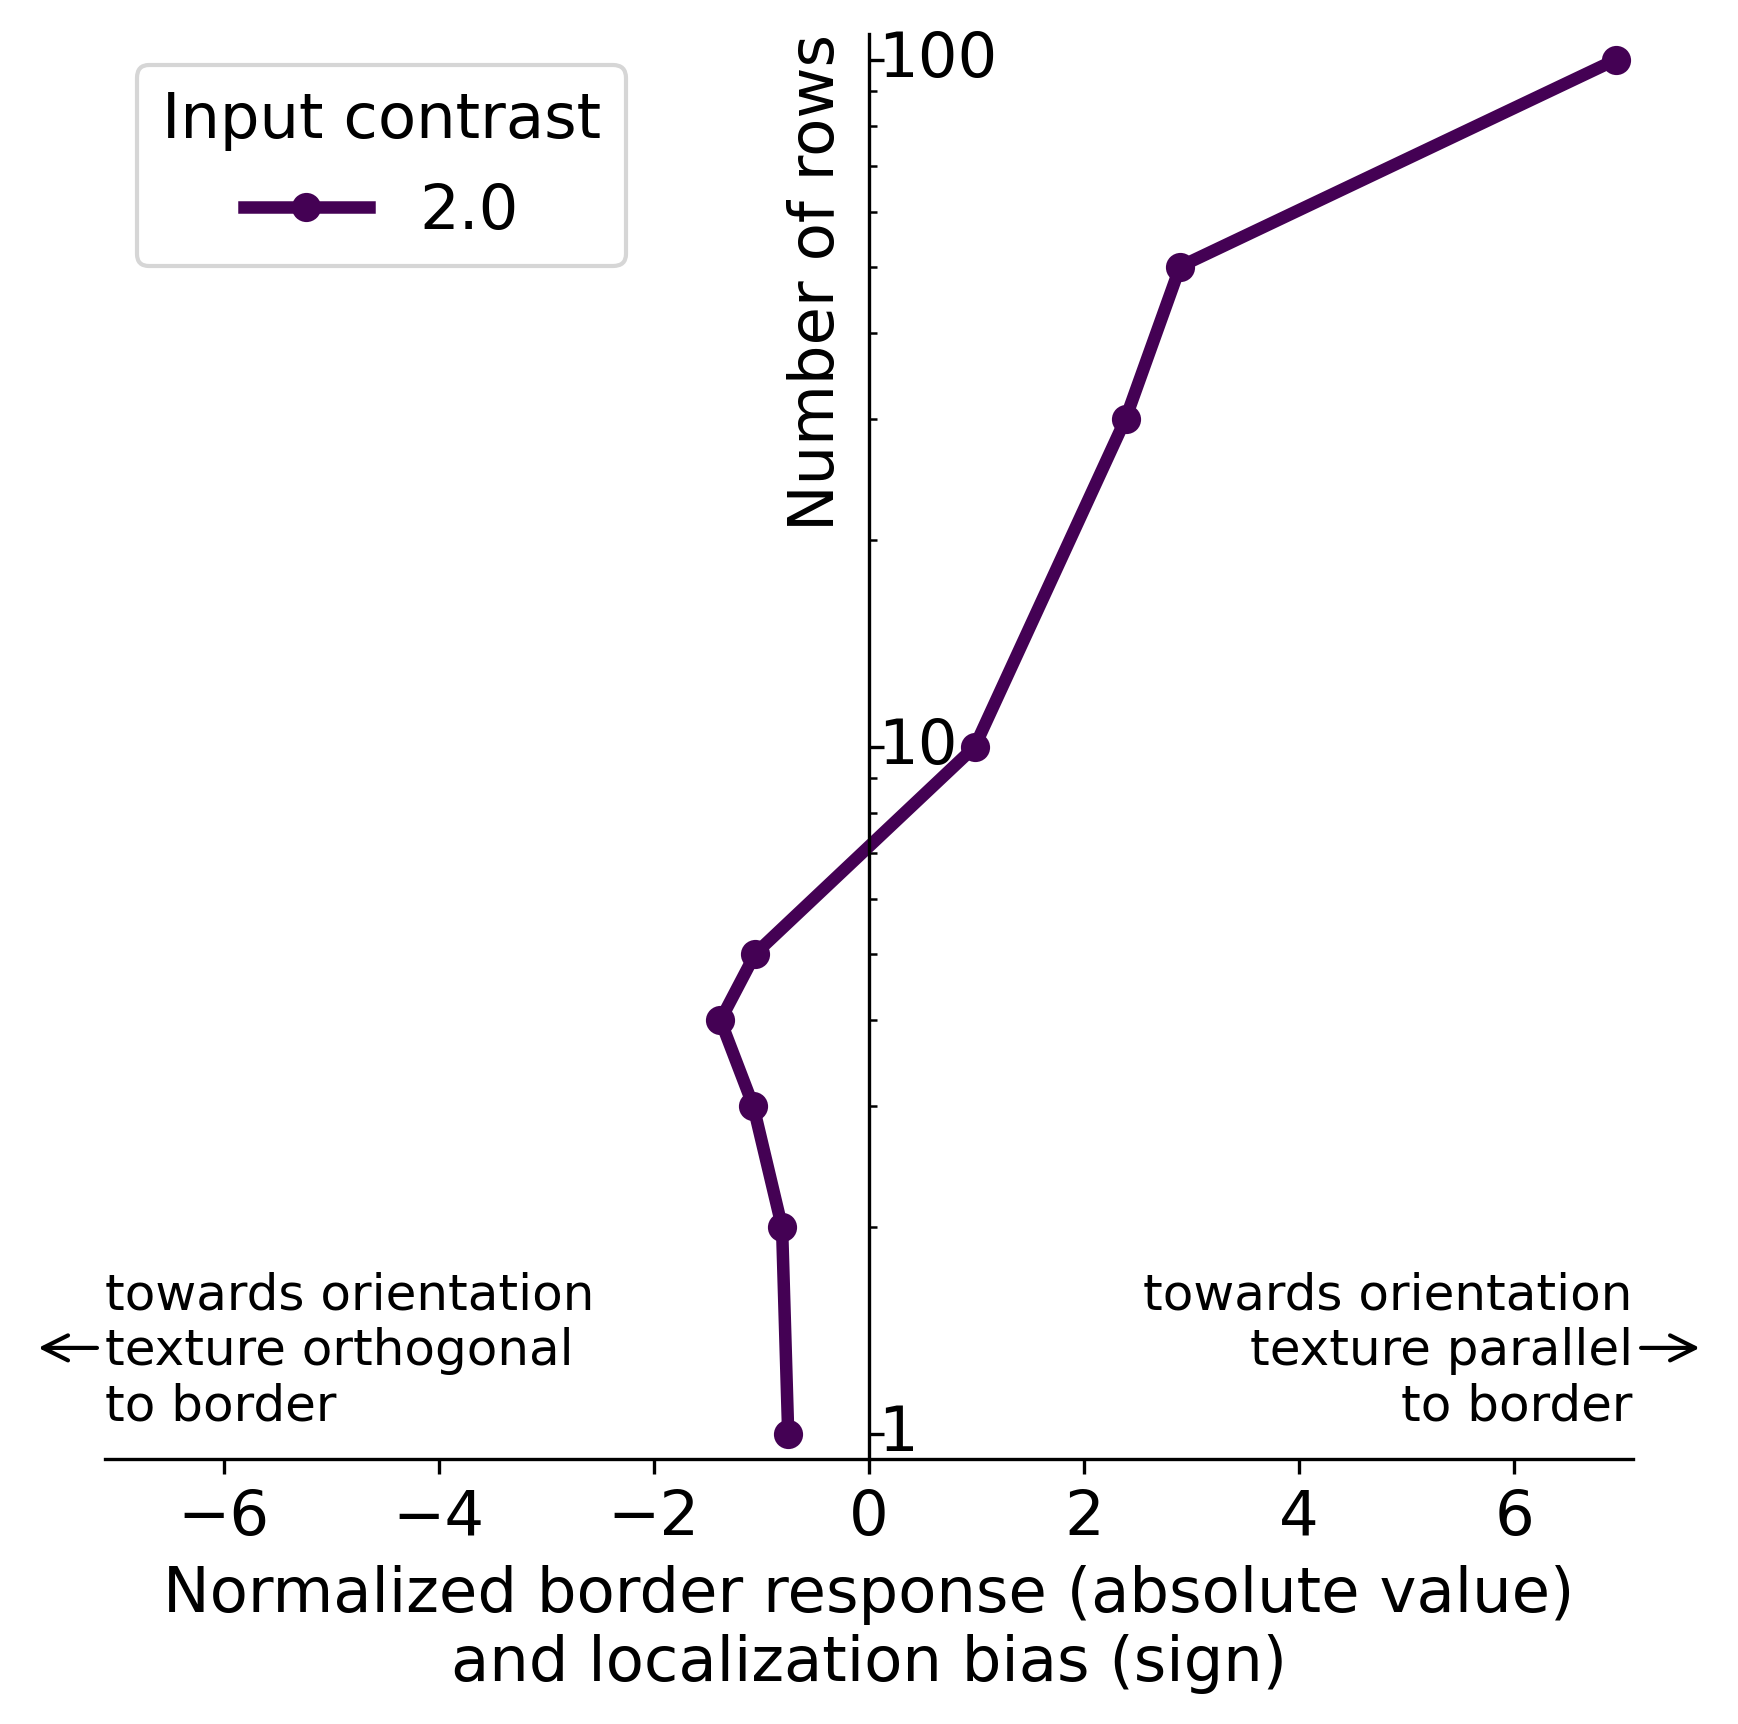

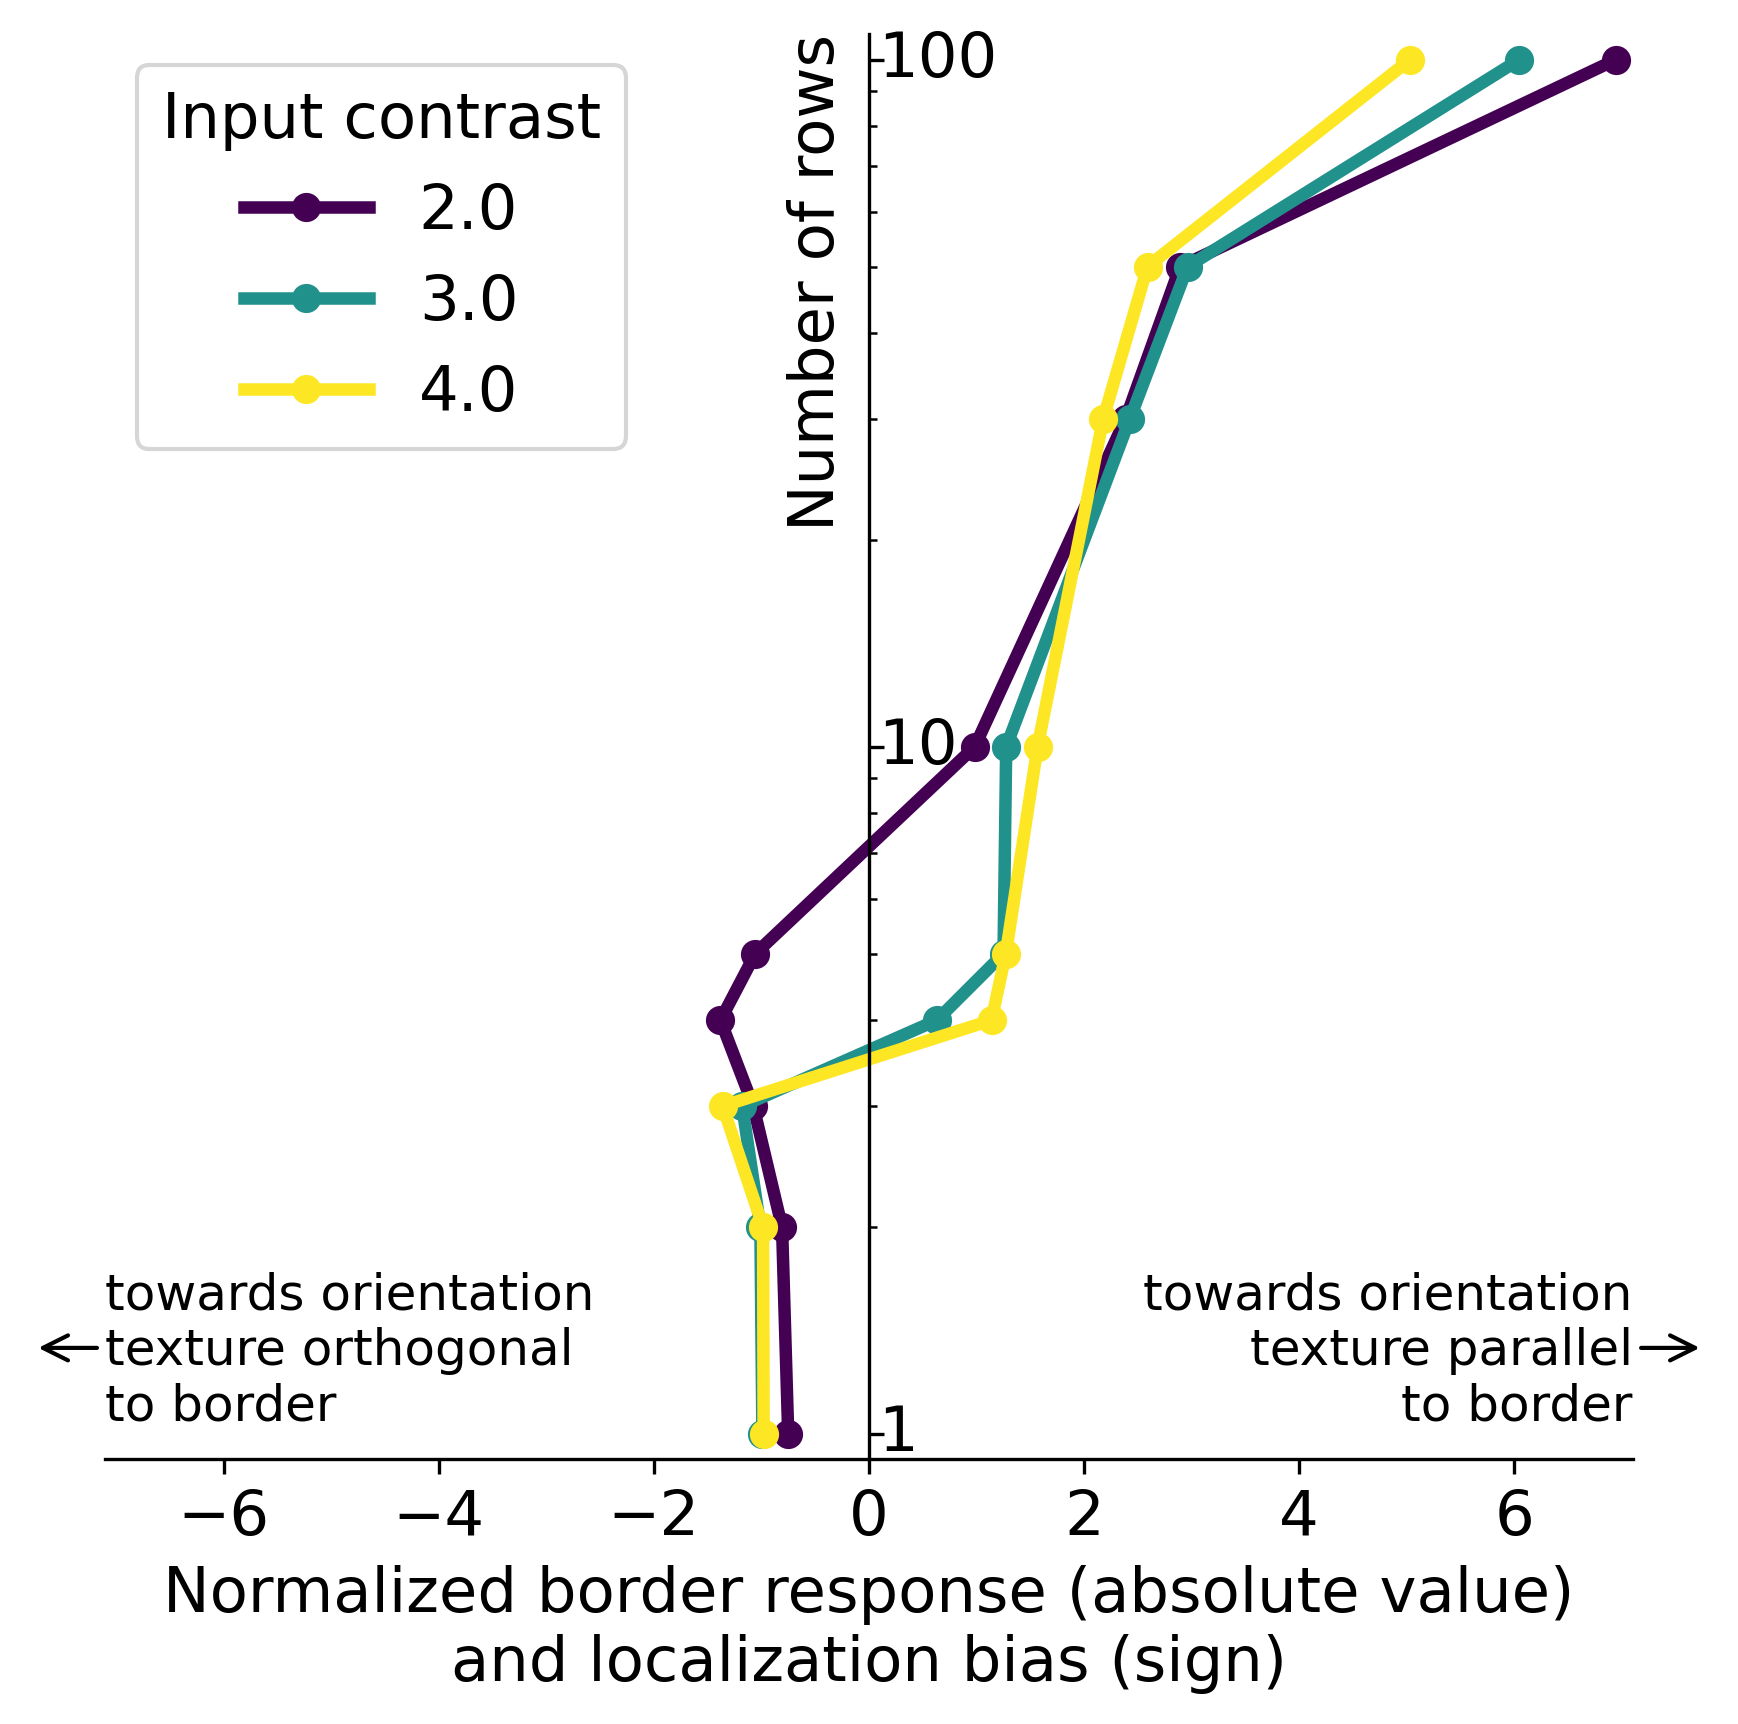

In [9]:
for choose_input in [0, None]:
    plt.figure(figsize=(6, 6), dpi = 300)
    plt.rcParams.update({'font.size': 15})
    colors = plt.cm.viridis(np.linspace(0, 1, len(border_saliencies.keys())))

    for idx, (color, I_input) in enumerate(zip(colors, border_saliencies.keys())):
        if choose_input is not None:
            if idx != choose_input:
                continue

        border_saliency = np.array(border_saliencies[I_input])
        assert np.all(border_saliency >= 0), "Border saliency should be non-negative for the plot to work."
        border_bias = np.array(border_biases[I_input])
        
        bias_neg_mask = np.array(border_bias) < 0
        border_saliency_score = border_saliency.copy()
        border_saliency_score[bias_neg_mask] = -border_saliency[bias_neg_mask]
        plt.plot(border_saliency_score, N_rows, marker="o", color=color, linewidth=3, label = f"{I_input}")

    # Remove top and right spines
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Move y-axis to cross x-axis at x=0
    ax.spines['left'].set_position(('data', 0))
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_tick_params(direction='in')
    ax.yaxis.set_tick_params(which='minor', direction='in')
    for tick in ax.yaxis.get_major_ticks():
        tick.label1.set_verticalalignment('center')
        tick.label1.set_horizontalalignment('left')
        tick.label1.set_x(0.22)  # Negative moves label inside; adjust as needed
    plt.xlim(-7.1, 7.1)
    plt.ylim(0.92, 109)
    plt.yscale('log')
    from matplotlib.ticker import FuncFormatter
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:g}'.format(y)))
    plt.ylabel("Number of rows",
                loc="top",        # Position label at the top
                labelpad=2)      # Optional: add padding for better spacing
    plt.xlabel("Normalized border response (absolute value)\nand localization bias (sign)")
    ax.text(
        plt.xlim()[1], 1.1 * plt.ylim()[0],  # x, y coordinates (slightly above axis)
        "towards orientation\ntexture parallel\nto border",
        ha='right', va='bottom', fontsize=12
    )
    ax.annotate(
        '', 
        xy=(plt.xlim()[1], 1.45 * plt.ylim()[0]),           # Arrow tip (same as text position)
        xytext=(plt.xlim()[1] + 0.7, 1.45 * plt.ylim()[0]),   # Arrow tail (shift right)
        arrowprops=dict(arrowstyle="<-", color='black', lw=1)
    )
    ax.text(
        plt.xlim()[0], 1.1 * plt.ylim()[0],  # x, y coordinates (slightly above axis)
        "towards orientation\ntexture orthogonal\nto border",
        ha='left', va='bottom', fontsize=12
    )
    ax.annotate(
        '', 
        xy=(plt.xlim()[0], 1.45 * plt.ylim()[0]),           # Arrow tip (same as text position)
        xytext=(plt.xlim()[0] - 0.7, 1.45 * plt.ylim()[0]),   # Arrow tail (shift right)
        arrowprops=dict(arrowstyle="<-", color='black', lw=1)
    )
    plt.legend(title="Input contrast")
    # plt.title("Predicted contextual influences\non border saliency and bias")
    plt.tight_layout()
    plt.show()

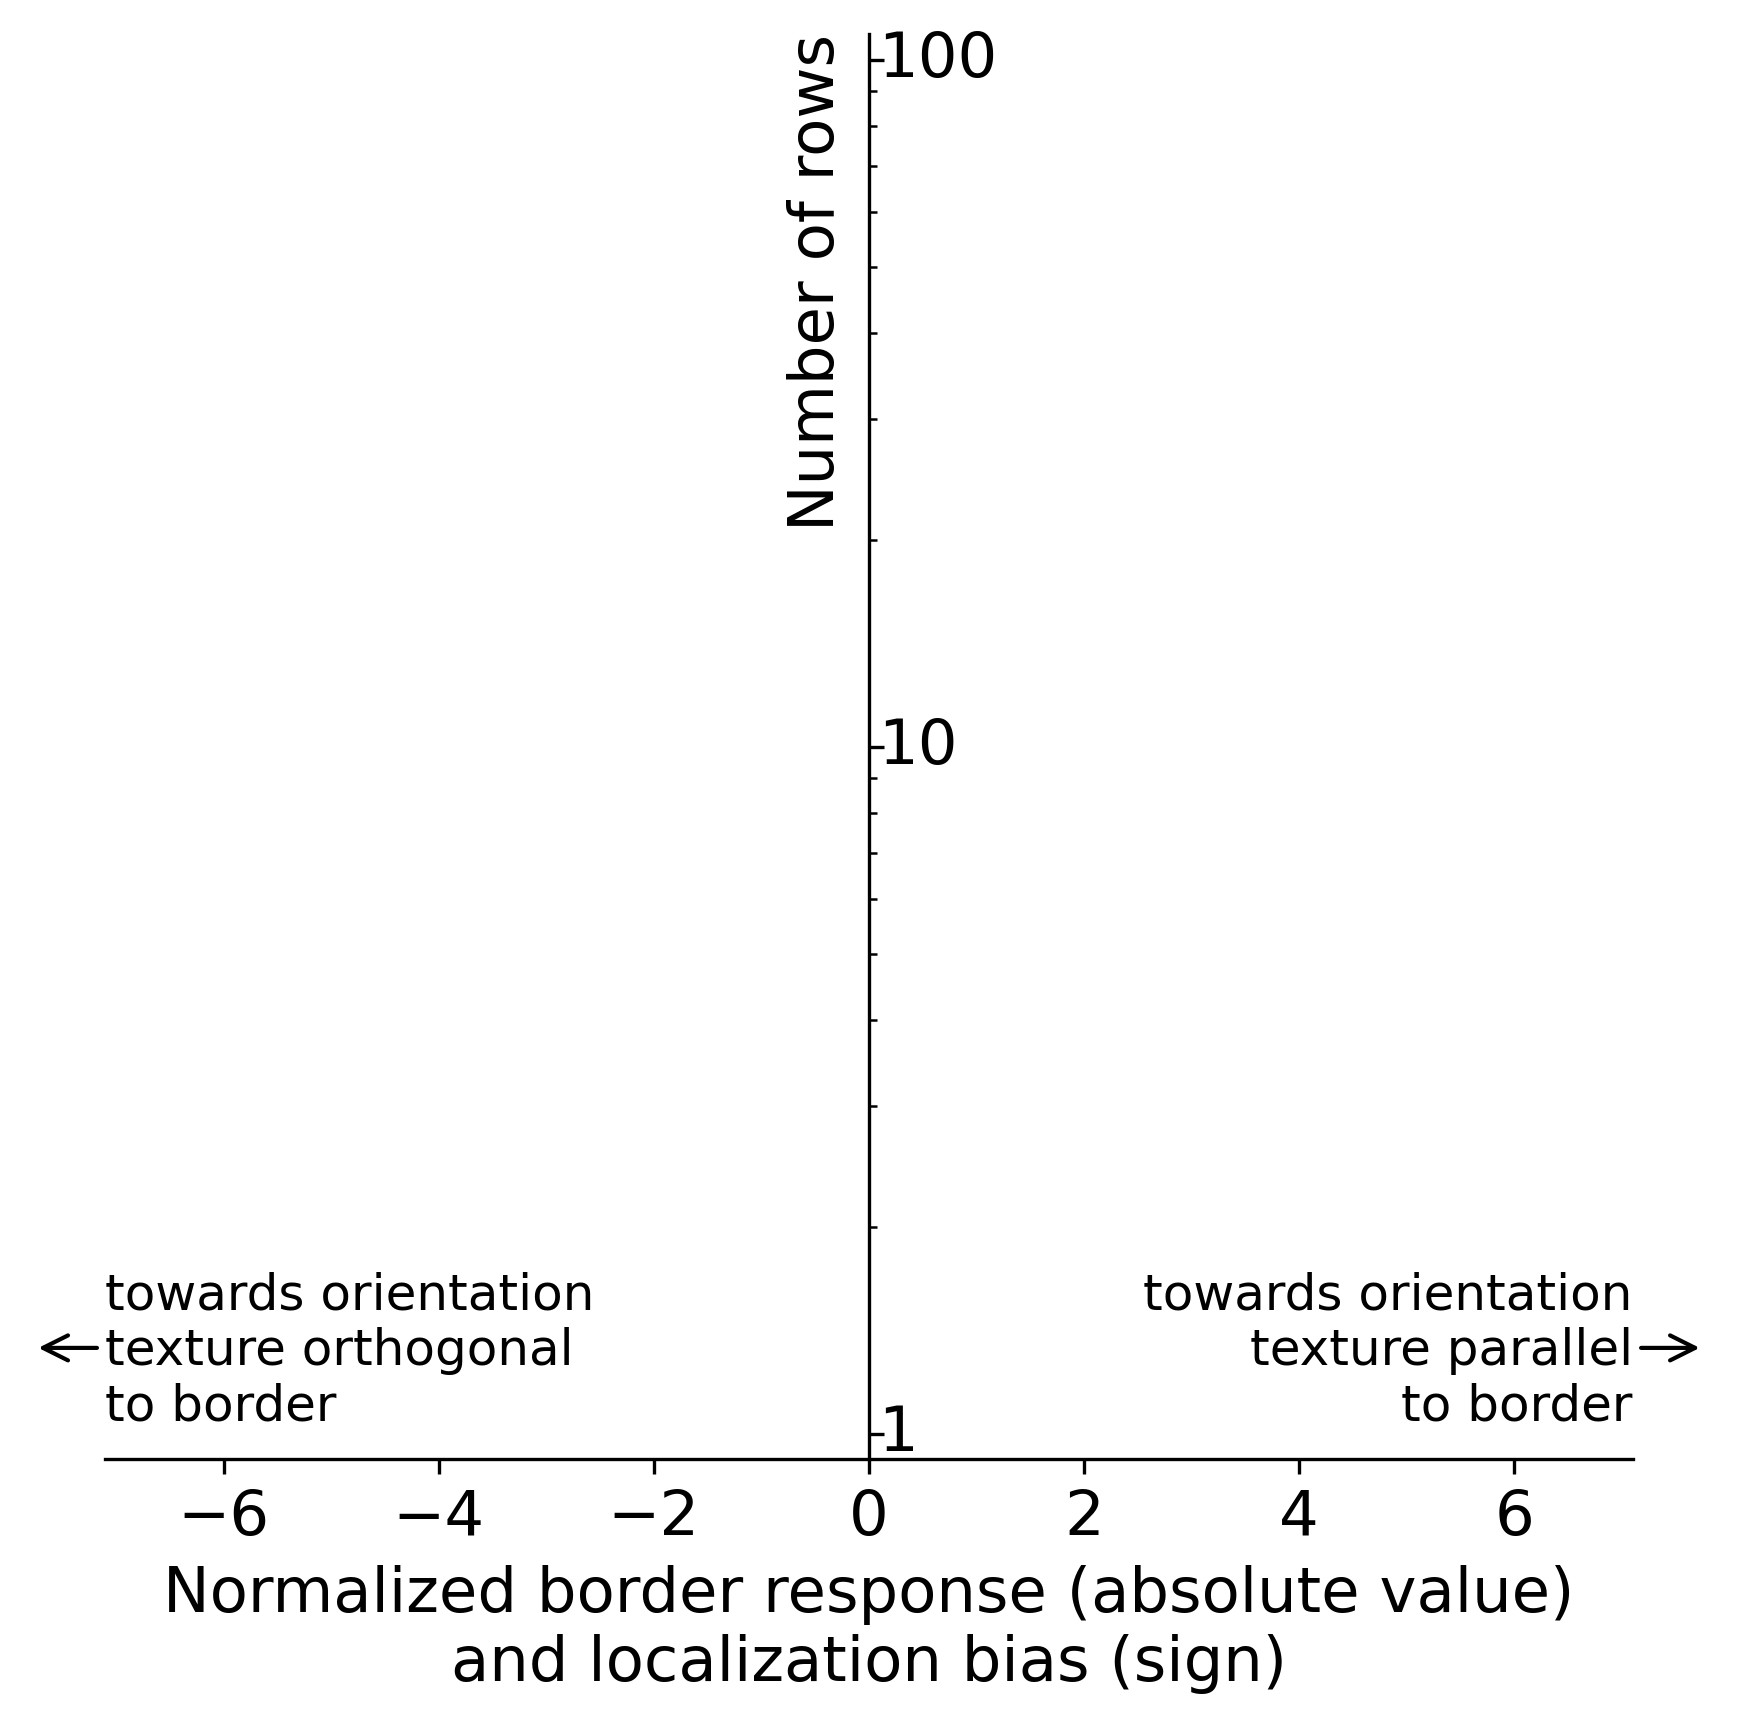

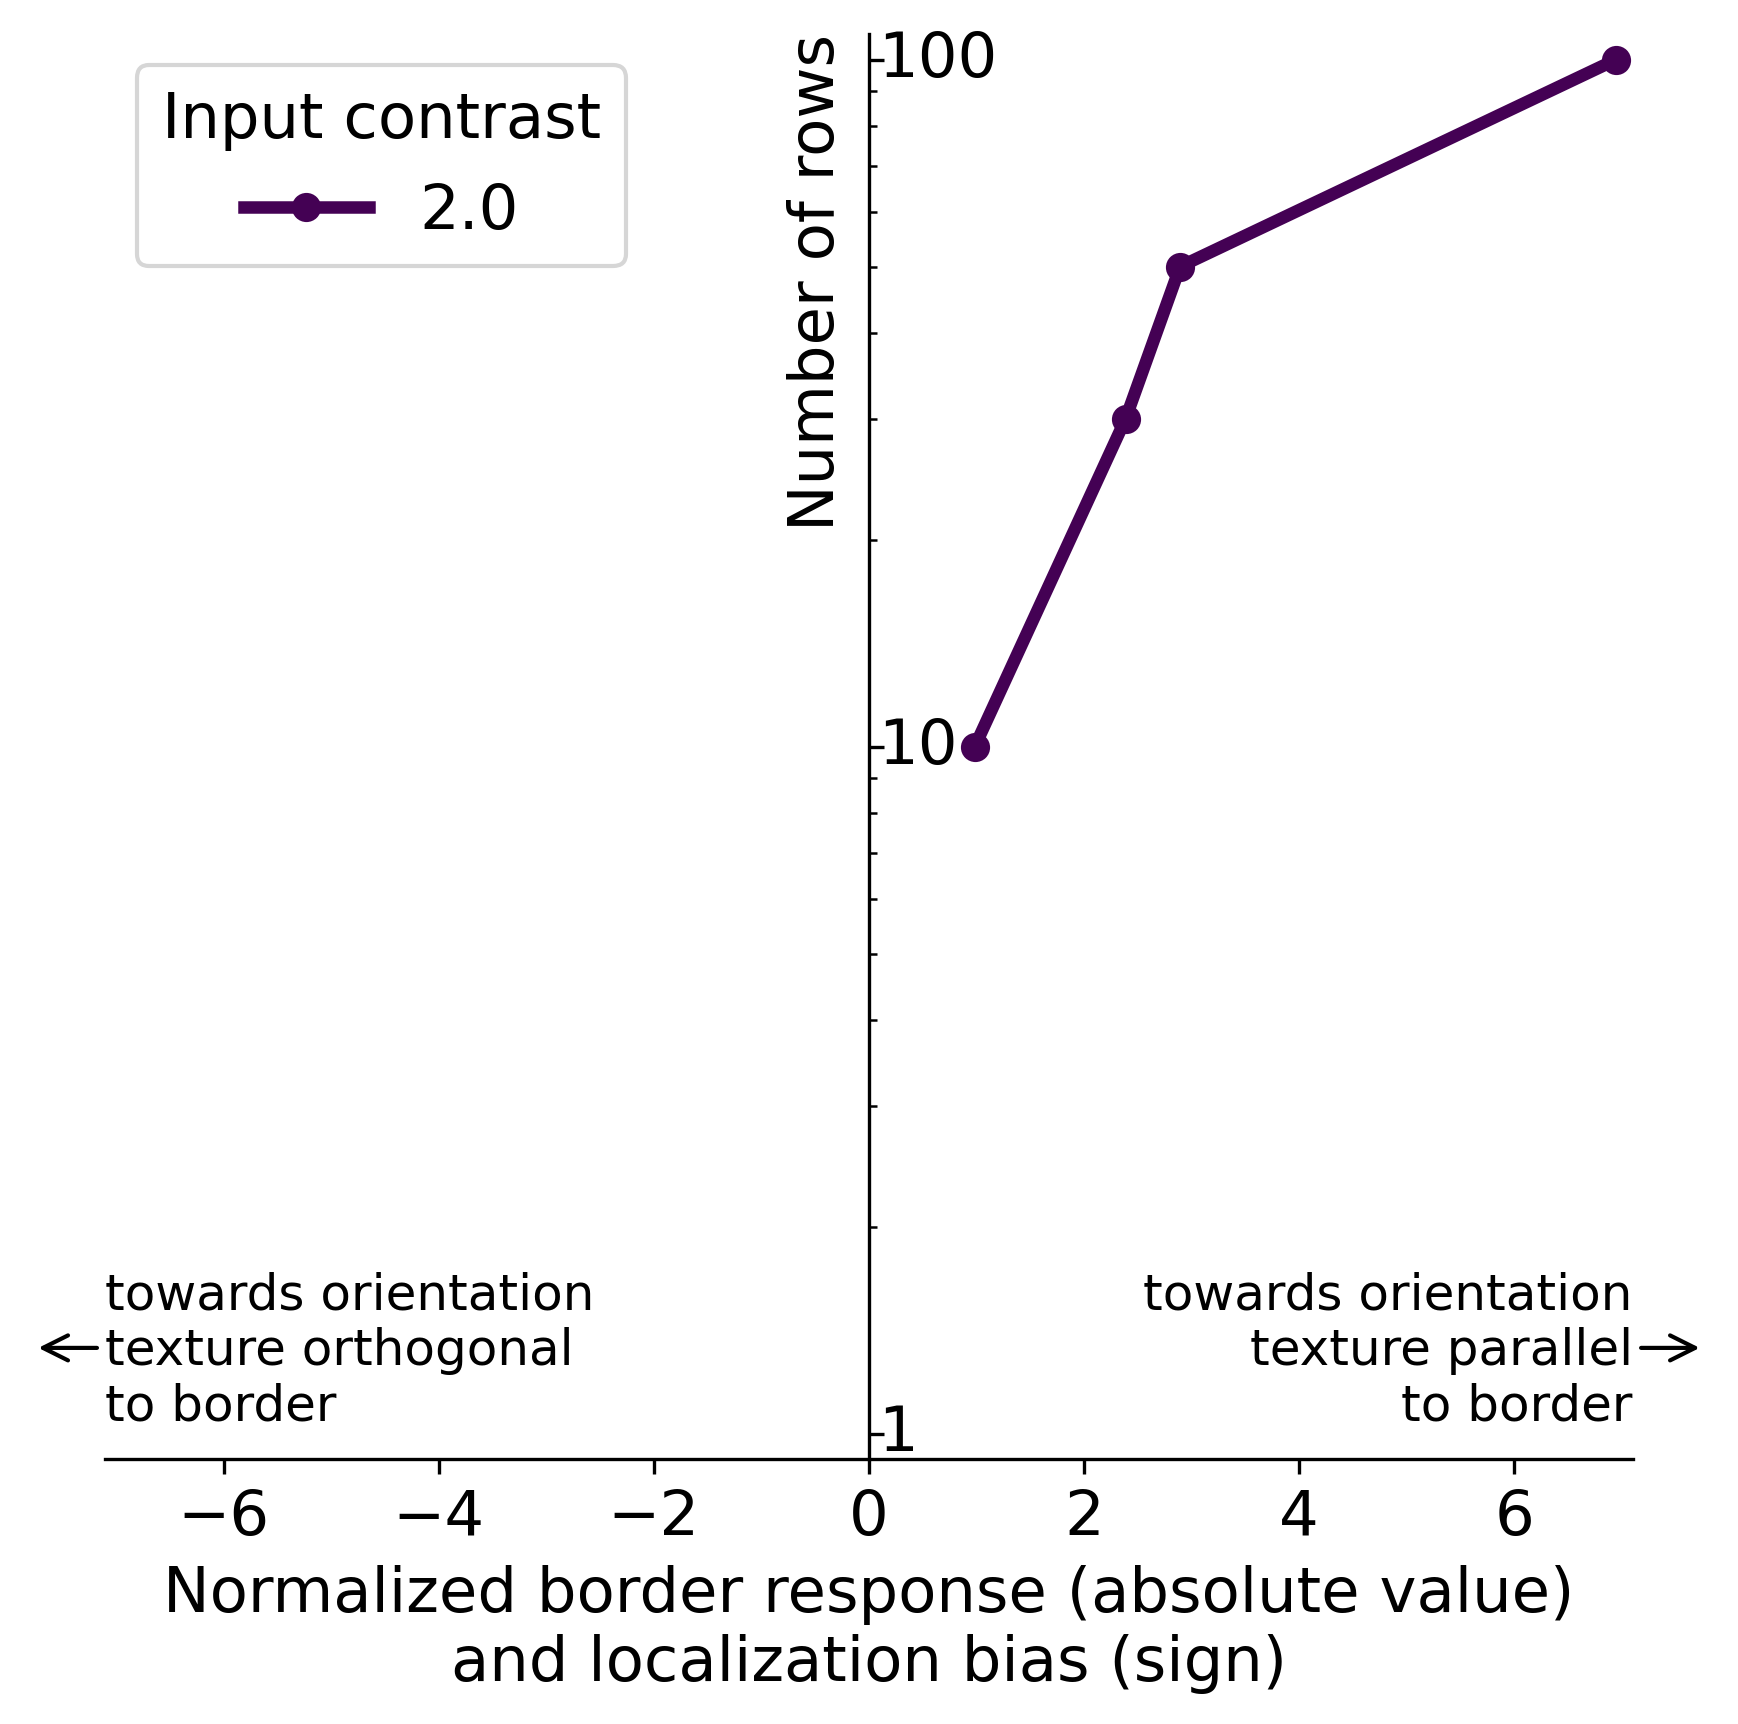

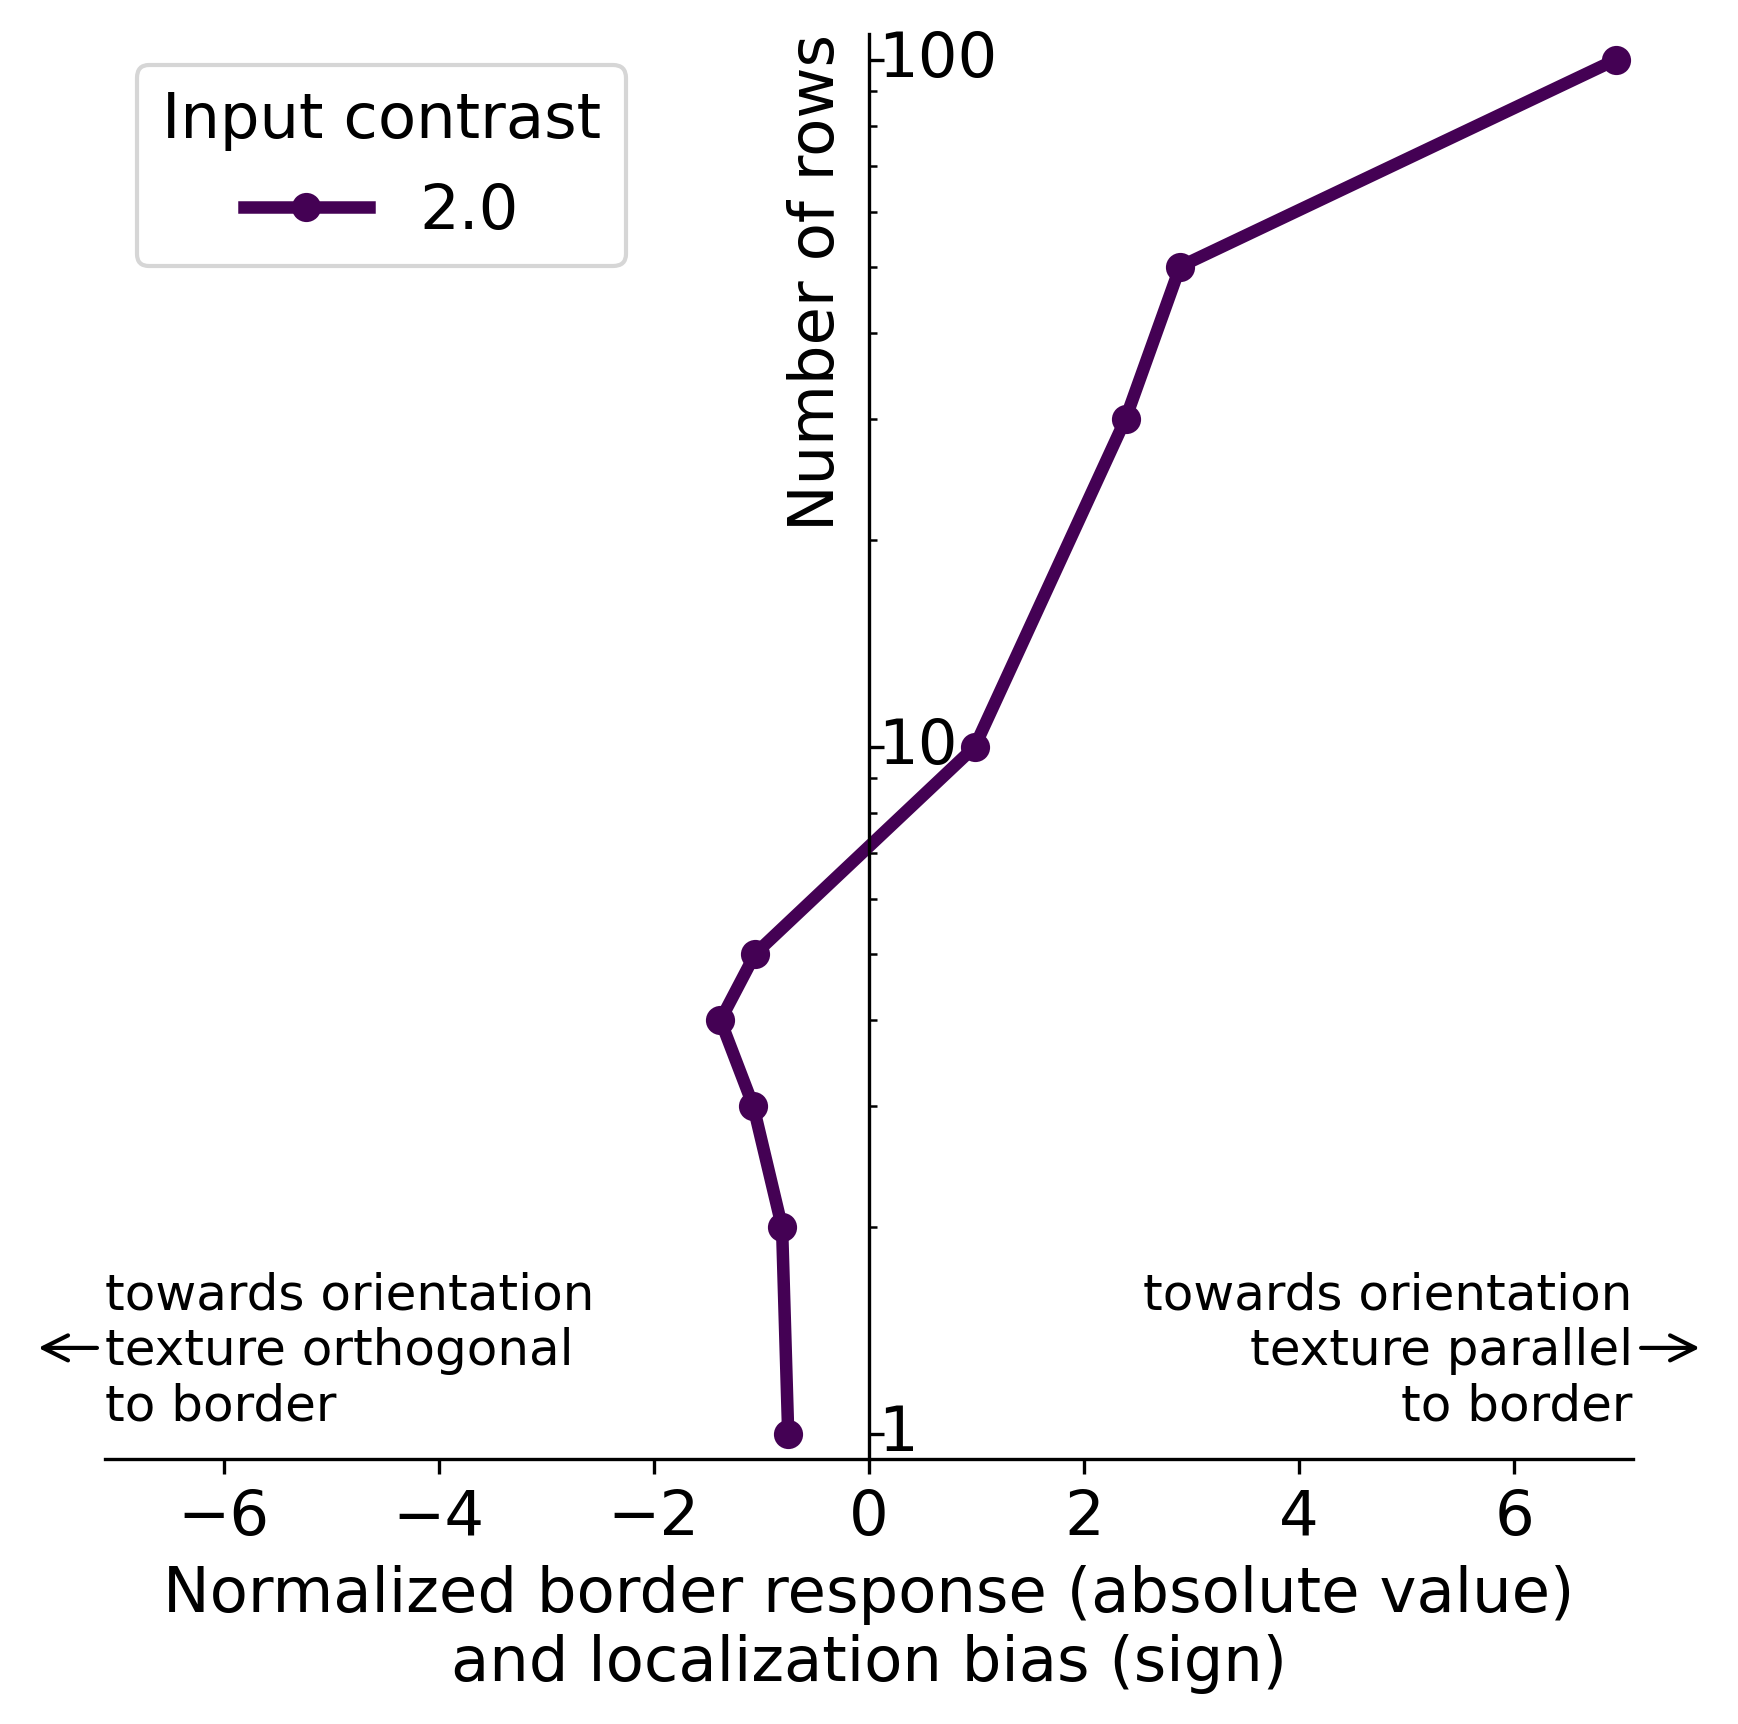

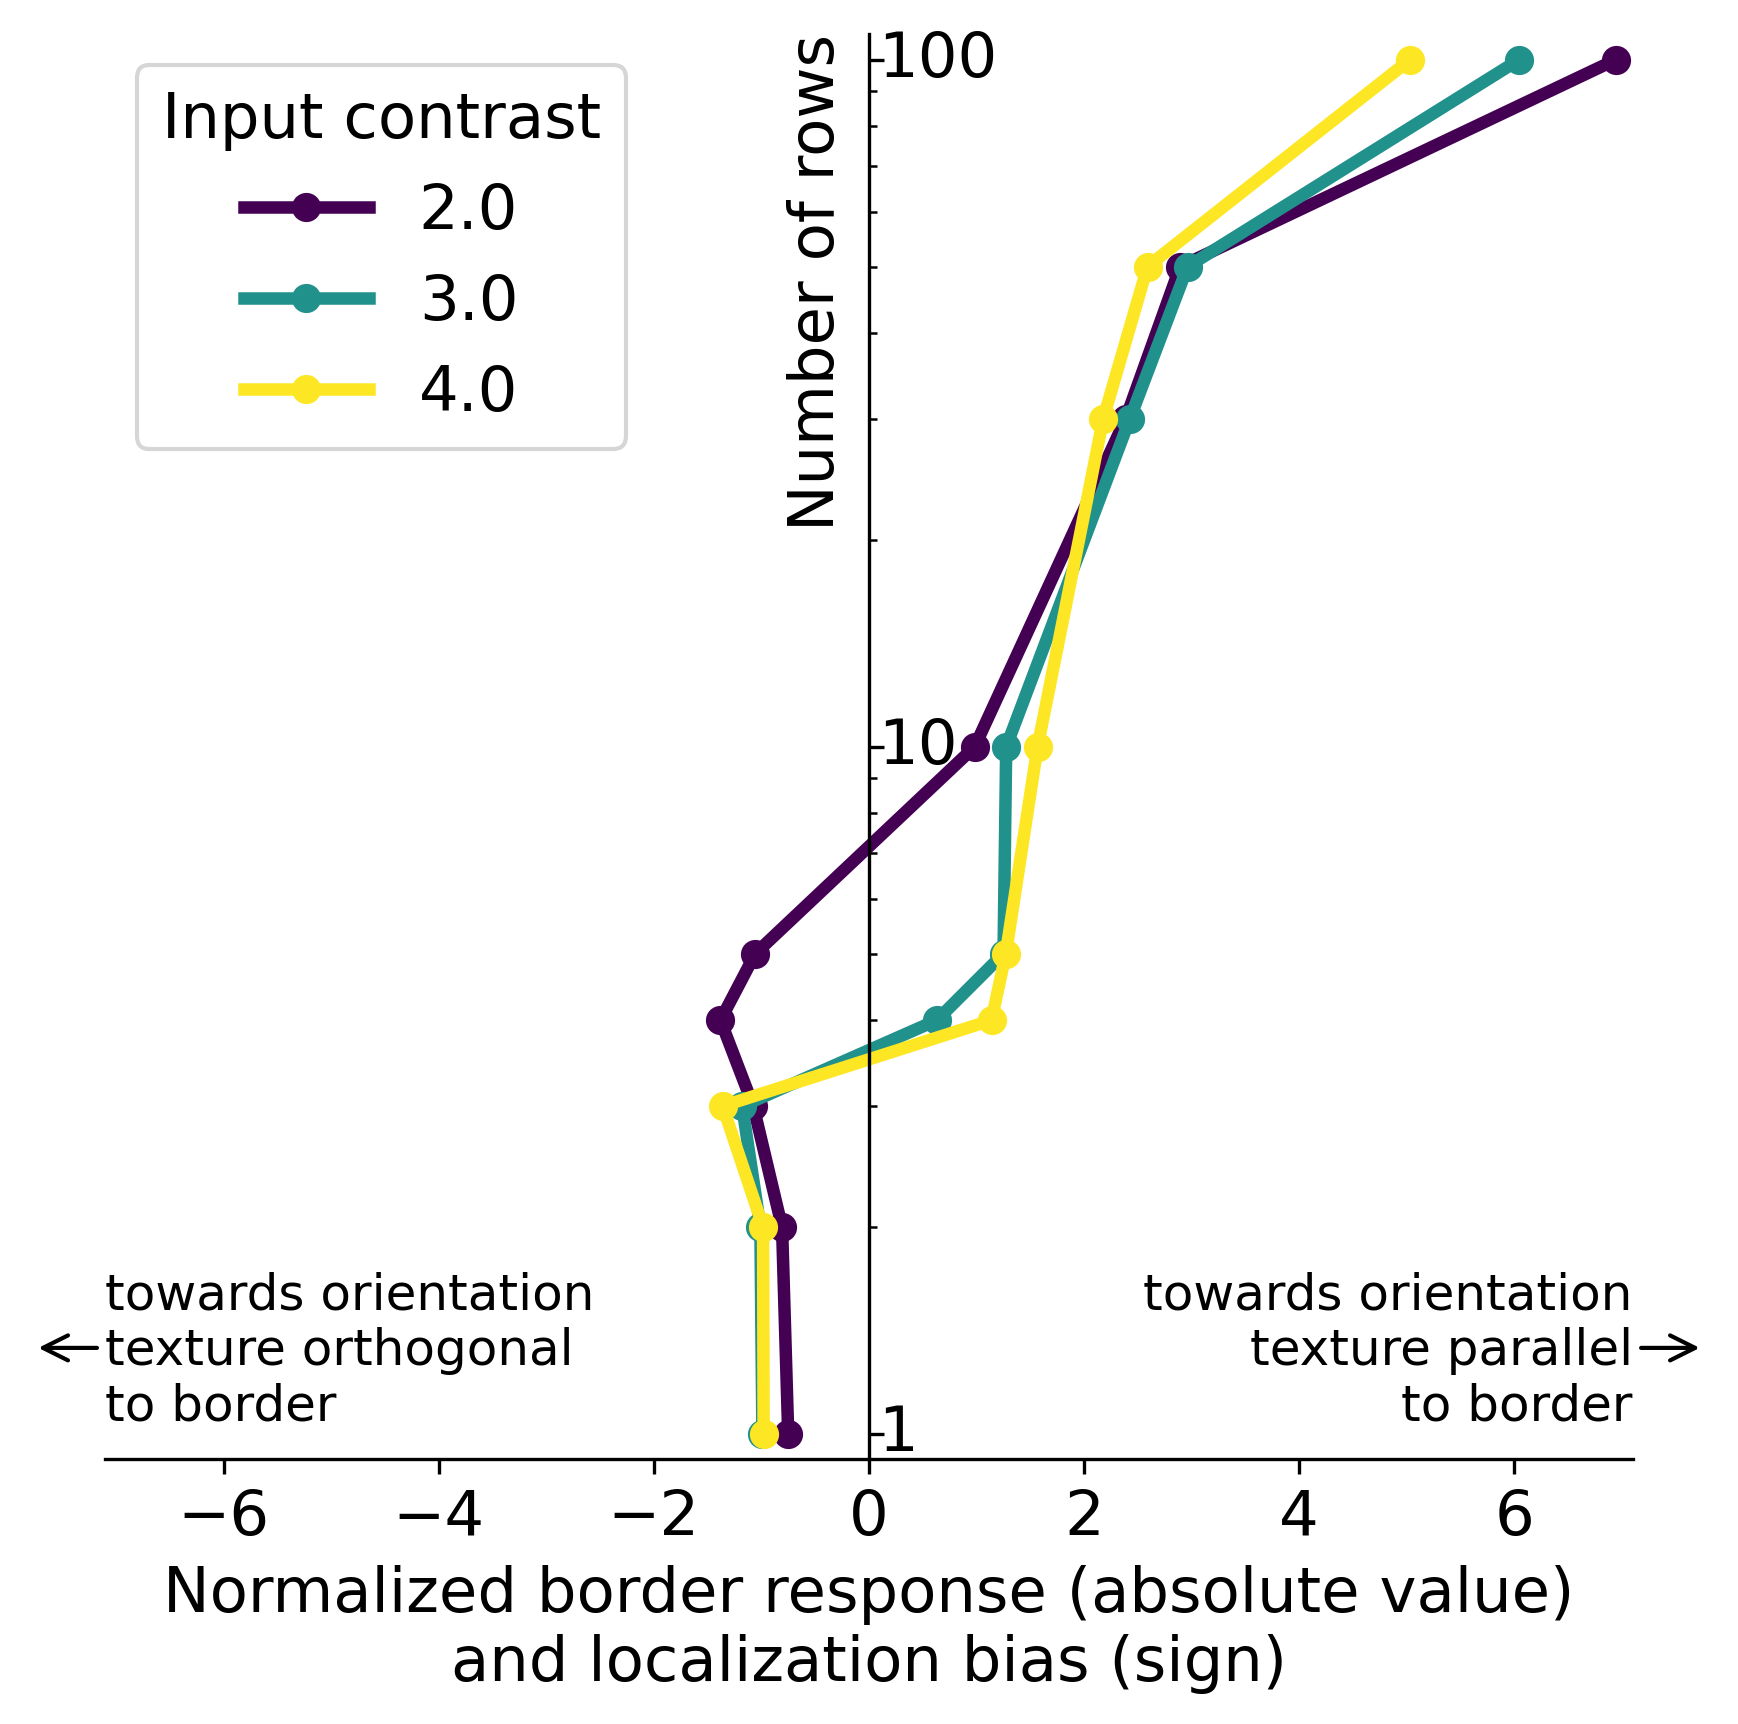

In [18]:
for choose_input in [0, None]:
    if choose_input is None:
        plot_data = [None] # all
    else:
        plot_data = [[], [-1, -2, -3, -4], None]
    
    for data_points_to_plot in plot_data:
        plt.figure(figsize=(6, 6), dpi = 300)
        plt.rcParams.update({'font.size': 15})
        colors = plt.cm.viridis(np.linspace(0, 1, len(border_saliencies.keys())))

        for idx, (color, I_input) in enumerate(zip(colors, border_saliencies.keys())):
            if choose_input is not None:
                if idx != choose_input:
                    continue

            border_saliency = np.array(border_saliencies[I_input])
            assert np.all(border_saliency >= 0), "Border saliency should be non-negative for the plot to work."
            border_bias = np.array(border_biases[I_input])
            
            bias_neg_mask = np.array(border_bias) < 0
            border_saliency_score = border_saliency.copy()
            border_saliency_score[bias_neg_mask] = -border_saliency[bias_neg_mask]
            
            if data_points_to_plot is not None:
                border_saliency_score = border_saliency_score[data_points_to_plot]
                N_rows_subset = np.array(N_rows)[data_points_to_plot]
                plt.plot(border_saliency_score, N_rows_subset, marker="o", color=color, linewidth=3, label = f"{I_input}")
            else:
                plt.plot(border_saliency_score, N_rows, marker="o", color=color, linewidth=3, label = f"{I_input}")

        # Remove top and right spines
        ax = plt.gca()
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Move y-axis to cross x-axis at x=0
        ax.spines['left'].set_position(('data', 0))
        ax.yaxis.set_ticks_position('left')
        ax.xaxis.set_ticks_position('bottom')
        ax.yaxis.set_tick_params(direction='in')
        ax.yaxis.set_tick_params(which='minor', direction='in')
        for tick in ax.yaxis.get_major_ticks():
            tick.label1.set_verticalalignment('center')
            tick.label1.set_horizontalalignment('left')
            tick.label1.set_x(0.22)  # Negative moves label inside; adjust as needed
        plt.xlim(-7.1, 7.1)
        plt.ylim(0.92, 109)
        plt.yscale('log')
        from matplotlib.ticker import FuncFormatter
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:g}'.format(y)))
        plt.ylabel("Number of rows",
                    loc="top",        # Position label at the top
                    labelpad=2)      # Optional: add padding for better spacing
        plt.xlabel("Normalized border response (absolute value)\nand localization bias (sign)")
        ax.text(
            plt.xlim()[1], 1.1 * plt.ylim()[0],  # x, y coordinates (slightly above axis)
            "towards orientation\ntexture parallel\nto border",
            ha='right', va='bottom', fontsize=12
        )
        ax.annotate(
            '', 
            xy=(plt.xlim()[1], 1.45 * plt.ylim()[0]),           # Arrow tip (same as text position)
            xytext=(plt.xlim()[1] + 0.7, 1.45 * plt.ylim()[0]),   # Arrow tail (shift right)
            arrowprops=dict(arrowstyle="<-", color='black', lw=1)
        )
        ax.text(
            plt.xlim()[0], 1.1 * plt.ylim()[0],  # x, y coordinates (slightly above axis)
            "towards orientation\ntexture orthogonal\nto border",
            ha='left', va='bottom', fontsize=12
        )
        ax.annotate(
            '', 
            xy=(plt.xlim()[0], 1.45 * plt.ylim()[0]),           # Arrow tip (same as text position)
            xytext=(plt.xlim()[0] - 0.7, 1.45 * plt.ylim()[0]),   # Arrow tail (shift right)
            arrowprops=dict(arrowstyle="<-", color='black', lw=1)
        )
        if data_points_to_plot is None or len(data_points_to_plot) > 1:
            plt.legend(title="Input contrast", loc ='upper left')
        # plt.title("Predicted contextual influences\non border saliency and bias")
        plt.tight_layout()
        plt.show()